In [1]:
import os
import copy
import pickle
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import similaritymeasures as sm
import matplotlib.patches as patches

from bisect import bisect
from scipy.stats import spearmanr
from matplotlib.gridspec import GridSpec
from processing_TowerCoordinates import *
from matplotlib.ticker import MaxNLocator
from processing_session_trajectory import *

plt.style.use('paper.mplstyle')


In [2]:
# Define the data folder path and the list of mice to analyze.

# path_to_data_folder points to the parent folder that contains one folder per mouse.

path_to_data_folder = '/home/david/MyLocalData/Lesions'

# Analyze the full cohort of mice.
mice_to_analyse = ['MOUB6JRj749','MOUB6JRj750','MOUB6JRj752','MOU5468','MOU5500', 'MOUB6JRj755','MOU5289','MOU5415','MOU5471','MOU5496',
                   'MOUB6JRj748','MOUB6JRj751','MOU5465','MOU5501','MOUB6JRj753','MOUB6JRj756','MOU5291','MOU5413','MOU5498']

# Verify that every mouse folder listed in mice_to_analyse exists in path_to_data_folder.
missing_folders = [mouse for mouse in mice_to_analyse if not os.path.isdir(os.path.join(path_to_data_folder, mouse))]

if missing_folders:
    print("Missing mice folders:", missing_folders)
else:
    print("All mice folders are present in data folder.")

# Print the number of mice and their identifiers.
print(f' {len(mice_to_analyse)} {"mice" if len(mice_to_analyse) > 1 else "mouse"} will be analysed\n')

# Select the session range to analyze for each mouse, starting from the first familiarization session.
first_and_last_session_indexes = [0,32]
# Select the session range to include in statistical analyses.
first_and_last_session_indexes_stats = [1,32]


All mice folders are present in data folder.
 19 mice will be analysed



In [3]:
GROUP1_ANIMALS: list[str] = ['MOUB6JRj748','MOUB6JRj751','MOU5465','MOU5501',
                           'MOUB6JRj753','MOUB6JRj756','MOU5291','MOU5413','MOU5498']
GROUP2_ANIMALS: list[str] = ['MOUB6JRj749','MOUB6JRj750','MOUB6JRj752','MOU5468','MOU5500',
                             'MOUB6JRj755','MOU5289','MOU5415','MOU5471','MOU5496']

# Update these labels to rename the experimental groups.
groups = {
    "Group 1": GROUP1_ANIMALS,
    "Group 2": GROUP2_ANIMALS
}


## Global parameters and functions

In [4]:
# Arena parameters

arena_coordinates_cm=[[2.5, 91.7], [90.3, 91.7], [90.3, 2.7], [2.5, 2.7]]

border_zone = [
    [(3, 3), (10, 3), (10, 90), (3, 90)],   # left
    [(3, 3), (3, 9.5), (92, 9.5), (92, 3)], # down
    [(84, 3), (92, 3), (92, 90), (84, 90)], # right
    [(3, 83), (3, 90), (92, 90), (92, 83)]  # up
]

trapeze_width = 30


In [5]:
# Global functions

def cm2inch(value):
    """Convert a length from centimeters to inches.
    
    Parameters:
    value : float or array-likeLength value(s) expressed in centimeters.
    
    Returns:
    float or array-like. The same length value(s) converted to inches."""
    return value / 2.54

def get_day_and_period(session_idx):
    """Map a zero-based session index to an experimental day and period.
    
    Parameters:
    session_idx : int. Zero-based session index, where sessions 0 and 1 correspond to day 1 AM and PM, sessions 2 and 3 to day 2 AM and PM, and so on.

    Returns: tuple[int, str]. A pair (day, period)."""

    day = session_idx // 2 + 1
    period = 'AM' if session_idx % 2 == 0 else 'PM'
    return day, period

def finding_mouse_rewarded_direction(folder_path_mouse_to_process, session_index):
    """Read the rewarded turn direction configured for a mouse session.
    
    Parameters:
    folder_path_mouse_to_process : str or path-like. Path to one mouse folder.
    session_index : int. Zero-based index into the sorted list of session folders.
    
    Returns:
    str or None:
        "CW" if 270 degrees is rewarded, "CCW" if 90 degrees is rewarded, "both" if both directions are rewarded, and "X" if reward delivery is disabled.
        Returns None when the parameter file contains an unexpected rewarded-direction value."""

    sessions_to_process = sorted([
        name for name in os.listdir(folder_path_mouse_to_process)
        if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
        and name.startswith('MOU')
    ])

    session_traj_df, session_turns_df, session_param_df = load_data(folder_path_mouse_to_process,sessions_to_process[session_index])

    rewarded_direction_degrees = session_param_df["potentialRewardedDirections"][0]

    if session_param_df["allowRewardDelivery"][0]:
        if rewarded_direction_degrees == '[270]':
            rewarded_direction = 'CW'
        elif rewarded_direction_degrees == '[90]':
            rewarded_direction = 'CCW'
        elif rewarded_direction_degrees == '[90, 270]':
            rewarded_direction = 'both'
        else:
            print('ERROR: Unexpected rewarded direction value:', rewarded_direction_degrees)
            return None
    else:
        rewarded_direction = 'X'

    return rewarded_direction

def finding_mouse_timeout(folder_path_mouse_to_process, session_index):
    """Read the timeout value configured for a mouse session.
    
    Parameters:
    folder_path_mouse_to_process : str or path-like. Path to one mouse folder containing session subfolders named with the ``"MOU"`` prefix.
    session_index : int. Zero-based index into the sorted session-folder list.
    
    Returns:
    int, float, or None. Timeout value extracted from the session parameter dataframe."""

    sessions_to_process = sorted([
        name for name in os.listdir(folder_path_mouse_to_process)
        if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
        and name.startswith('MOU')
    ])

    try:
        session_traj_df, session_turns_df, session_param_df = load_data(
            folder_path_mouse_to_process,
            sessions_to_process[session_index]
        )
    except Exception:
        return None

    if session_param_df is None:
        return None

    if 'Timeout' not in session_param_df.columns:
        return None

    timeout_value = session_param_df['Timeout'].iloc[0]

    if pd.isna(timeout_value):
        return None

    try:
        if isinstance(timeout_value, str):
            timeout_value = timeout_value.strip().replace('[', '').replace(']', '')
            if timeout_value == '':
                return None
            timeout_value = float(timeout_value)
        else:
            timeout_value = float(timeout_value)
    except Exception:
        return None

    if timeout_value.is_integer():
        timeout_value = int(timeout_value)

    return timeout_value

def add_timeout_background(ax, all_sessions, folder_path_reference_mouse, index_offset=0, session_threshold=21, alpha=0.18):
    """Shade sessions according to timeout condition on an existing Matplotlib axis.
    
    Parameters:
    ax: matplotlib.axes.Axes. Axis on which vertical background spans will be drawn.
    all_sessions: iterable of int. One-based session numbers to inspect and potentially shade.
    folder_path_reference_mouse: str or path-like. Mouse folder used as a reference for session-level timeout values.
    index_offset: int or float, default=0. Horizontal offset applied to session numbers when plotting.
    session_threshold: int, default=21. First one-based session number for which timeout shading should be applied. Earlier sessions are ignored.
    alpha: float, default=0.18. Transparency of the background spans.
    
    Returns:
    None: The function modifies `ax` in place."""

    timeout_colors = {
        0: 'lightgreen',
        5: '#ffe699',
        15: '#f4a3a3'
    }

    for session in all_sessions:
        if session < session_threshold:
            continue

        zero_based_session_index = session - 1

        timeout_value = finding_mouse_timeout(
            folder_path_reference_mouse,
            zero_based_session_index
        )

        if timeout_value not in timeout_colors:
            continue

        ax.axvspan(
            session + index_offset - 0.49,
            session + index_offset + 0.49,
            ymin=0,
            ymax=1,
            color=timeout_colors[timeout_value],
            alpha=alpha,
            zorder=-2,
            lw=0
        )

def filter_qts(qts):
    """Filter quarter-turn epochs to keep clean single-trapeze-switch turns.
    
    Parameters:
    qts : list. List of quarter-turn epoch records.
    
    Returns:
    list. Subset of qts where num_trapezeswitch == 1 and epoch_distance <= 30. The original epoch objects are returned without copying."""
    
    filtered_qts = []

    for qt in qts:
        if qt[3]['num_trapezeswitch'] != 1:
            continue
        if qt[4]['epoch_distance'] > 30:
            continue
        filtered_qts.append(qt)

    return filtered_qts


In [6]:
# Plot functions

def get_group_summary(ax, mice_list, mouse_metric_persession, color, show_individual_mice, index_offset):

    all_session_indices = set()
    values_per_session = {}

    for mouse in mice_list:
        if mouse not in mouse_metric_persession:
            print(f"Mouse {mouse} not found in data. Skipping.")
            continue

        sessions = mouse_metric_persession[mouse]
        session_indices = [session[0] for session in sessions]
        values = [session[1] for session in sessions]

        session_indices_array = np.array(session_indices)
        values_array = np.array(values, dtype=float)

        mask = ~np.isnan(values_array)
        session_indices_clean = session_indices_array[mask]
        values_clean = values_array[mask]

        if show_individual_mice and len(session_indices_clean) > 0:
            ax.plot(
                session_indices_clean + index_offset,
                values_clean,
                marker='o',
                linewidth=0.7,
                markersize=1,
                alpha=0.25,
                color=color,
                zorder=1
            )

        all_session_indices.update(session_indices_clean)

        for session, value in zip(session_indices_clean, values_clean):
            if session not in values_per_session:
                values_per_session[session] = []
            values_per_session[session].append(value)

    sorted_sessions = sorted(all_session_indices)

    median_values = []
    lower_quartile = []
    upper_quartile = []

    for session in sorted_sessions:
        session_values = values_per_session[session]
        median_values.append(np.nanmedian(session_values))
        lower_quartile.append(np.nanpercentile(session_values, 25))
        upper_quartile.append(np.nanpercentile(session_values, 75))

    return (
        np.array(sorted_sessions),
        np.array(median_values),
        np.array(lower_quartile),
        np.array(upper_quartile)
    )

def plot_learning_curves_two_groups(mouse_metric_persession, ax, group1_mice, group2_mice, group1_label='Group 1', group2_label='Group 2',
    group1_color='black', group2_color='red', show_individual_mice=True, ylabel='', show_xlabel=True, tick_interval=1, index_offset=0,
    xlim=[None, None], ylim=None, show_fam=False, show_legend=True, legend_loc=(0.05, 0.9)):

    """Plot and annotate learning curves for two mouse groups.
    
    Parameters:
    mouse_metric_persession : dict.Mapping from mouse identifier to (session_number, metric_value) pairs.
    ax : matplotlib.axes.Axes. Axis on which the learning curves are drawn.
    group1_mice, group2_mice : list[str]. Mouse identifiers for each group.
    group1_label, group2_label : str, default="Group 1", "Group 2". Labels used in the legend.
    group1_color, group2_color : str, default="black", "red". Colors for median curves, interquartile bands, and optional individual traces.
    show_individual_mice : bool, default=True. Whether to overlay faint per-mouse trajectories.
    ylabel : str, default="". Y-axis label.
    show_xlabel : bool, default=True. Whether to label the x-axis as session number.
    tick_interval : int, default=1. Spacing between x-axis session ticks.
    index_offset : int or float, default=0. Offset applied to session numbers when plotting.
    xlim : list, default=[None, None]. Optional x-axis limits passed to Matplotlib.
    ylim : tuple or None, default=None. Optional y-axis limits.
    show_fam : bool, default=False. Whether to label the early familiarization section.
    show_legend : bool, default=True. Whether to draw the legend.
    legend_loc : tuple or str, default=(0.05, 0.9). Legend location passed to Matplotlib.
    
    Returns:
    None. The function modifies ``ax`` in place."""

    s1, med1, q1_low, q1_high = get_group_summary(ax, group1_mice, mouse_metric_persession, group1_color, show_individual_mice, index_offset)
    s2, med2, q2_low, q2_high = get_group_summary(ax, group2_mice, mouse_metric_persession, group2_color, show_individual_mice, index_offset)

    if len(s1) > 0:
        ax.plot(s1 + index_offset, med1, color=group1_color, linewidth=2, zorder=10, alpha = 1,
                label=f'{group1_label} (n={len(group1_mice)})')
        ax.fill_between(s1 + index_offset, q1_low, q1_high, color=group1_color, alpha=0.2, linewidth=0, edgecolor='none', antialiased=False)

    if len(s2) > 0:
        ax.plot(s2 + index_offset, med2, color=group2_color, linewidth=2,zorder=10, alpha = 1,
                label=f'{group2_label} (n={len(group2_mice)})')
        ax.fill_between(s2 + index_offset, q2_low, q2_high, color=group2_color, alpha=0.2, linewidth=0, edgecolor='none', antialiased=False)

    if show_xlabel:
        ax.set_xlabel('Session Number', fontsize=7)

    ax.set_ylabel(ylabel, fontsize=7)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    all_sessions = sorted(set(list(s1) + list(s2)))
    if len(all_sessions) > 0:
        max_index = max(all_sessions)
        ax.set_xticks(range(1 + index_offset, max_index + 1 + index_offset, tick_interval))

        # Use the first mouse as a reference for session-level protocol parameters.
        first_mouse = list(mouse_metric_persession.keys())[0]
        folder_path_first_mouse = os.path.join(path_to_data_folder, first_mouse)

        # Add timeout background shading for the depleting protocol only, starting at session 21.
        add_timeout_background(ax=ax, all_sessions=all_sessions, folder_path_reference_mouse=folder_path_first_mouse, index_offset=index_offset,
            session_threshold=21, alpha=0.18)

        for session in all_sessions:

            zero_based_session_index = session - 1

            rewarded_direction = finding_mouse_rewarded_direction(
                folder_path_first_mouse,
                zero_based_session_index
            )

            if rewarded_direction == 'X':
                band_color = "orange"

            elif rewarded_direction == "both":
                band_color = "#a875bc"

            elif rewarded_direction == "CW" :
                band_color = "blue"

            elif rewarded_direction == "CCW":
                band_color = "red"

            ax.axvspan(session + index_offset - 0.49, session + index_offset + 0.49, ymin=0.979, ymax=0.998,
                color=band_color, zorder=3, clip_on=False)

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    ylimits = ax.get_ylim()
    rectangle_height = abs(ylimits[1] - ylimits[0])
    rect = patches.Rectangle((0.5, ylimits[0]), 2, rectangle_height, color='moccasin', alpha=1, lw=0, zorder=0)
    ax.add_patch(rect)

    if show_fam:
        ax.text(1.5, ylimits[1], "Fam.", fontsize=6, ha='center', va='bottom',
                fontweight='normal', color='orange', alpha=0.6, zorder=1000)

    if show_legend:
        ax.legend(frameon=False, loc=legend_loc)


In [7]:
# Pickle functions

def get_pickle_jar_path(folder_path_mouse_to_process, session_to_process):
    """Build and create the cache folder used for session-level pickle files.
    
    Parameters:
    folder_path_mouse_to_process : str or path-like. Path to the mouse folder.
    session_to_process : str. Name of the session subfolder.
    
    Returns:
    str. Path to the pickle_jar directory inside the session folder. The directory is created if it does not already exist."""

    session_folder = os.path.join(folder_path_mouse_to_process, session_to_process)
    pickle_jar_path = os.path.join(session_folder, "pickle_jar")
    os.makedirs(pickle_jar_path, exist_ok=True)
    return pickle_jar_path

def frechet_pickles_exist(pickle_jar_path, pickle_names):
    """Check whether all cached Fréchet metric files are present.
    
    Parameters:
    pickle_jar_path : str or path-like. Folder where cached pickle files should be stored.
    pickle_names : dict. Mapping from metric name to pickle filename. Only the filenames in the dictionary values are checked.
    
    Returns:
    bool. "True" if every expected pickle file exists in pickle_jar_path; otherwise "False"."""

    return all(
        os.path.exists(os.path.join(pickle_jar_path, filename))
        for filename in pickle_names.values()
    )

def save_frechet_pickles(pickle_jar_path, frechet_results,pickle_names):
    """Save Fréchet-distance results to individual pickle files.
    
    Parameters:
    pickle_jar_path : str or path-like. Destination cache folder.
    frechet_results : dict. Mapping from metric name to computed value. Keys must exist in ``pickle_names``.
    pickle_names : dict. Mapping from metric name to output filename.
    
    Returns:
    None. Results are written to disk."""

    for key, value in frechet_results.items():
        filepath = os.path.join(pickle_jar_path, pickle_names[key])
        with open(filepath, "wb") as f:
            pickle.dump(value, f)

def load_frechet_pickles(pickle_jar_path, pickle_names):
    """Load cached Fréchet-distance metrics from disk.
    
    Parameters:
    pickle_jar_path : str or path-like. Cache folder containing the expected pickle files.
    pickle_names : dict. Mapping from metric name to pickle filename.
    
    Returns:
    dict. Mapping from metric name to the object loaded from its corresponding pickle file."""

    frechet_results = {}
    for key, filename in pickle_names.items():
        filepath = os.path.join(pickle_jar_path, filename)
        with open(filepath, "rb") as f:
            frechet_results[key] = pickle.load(f)
    return frechet_results


### Total distance and average speed
Data extraction

In [8]:
# Collect total distance and average speed for each mouse and session.

total_distance_m = {mouse: [] for mouse in mice_to_analyse}
average_speeds = {mouse: [] for mouse in mice_to_analyse}

for mouse in mice_to_analyse:

    folder_path_mouse_to_analyse = os.path.join(path_to_data_folder, mouse)

    sessions_to_analyse = sorted([
        name for name in os.listdir(folder_path_mouse_to_analyse)
        if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
        and name.startswith('MOU')
    ])

    sessions_to_analyse = sessions_to_analyse[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    for sessionindex, session_to_analyse in enumerate(sessions_to_analyse):

        output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(
            folder_path_mouse_to_analyse,
            session_to_analyse,
            output_pickle_filename
        )

        # Store NaN values when the processed session file is missing.
        if not os.path.exists(output_pickle_filepath):
            total_distance_m[mouse].append([sessionindex + 1, np.nan])
            average_speeds[mouse].append([sessionindex + 1, np.nan])
            continue

        # Load the session processing pickle.
        with open(output_pickle_filepath, "rb") as f:
            data = pickle.load(f)

        # Convert cumulative distance from centimeters to meters.
        distances = data["distances"]
        total_distance = np.sum(distances)/100
        average_speed = data["average_speed"]

        total_distance_m[mouse].append([sessionindex + 1, total_distance])
        average_speeds[mouse].append([sessionindex + 1, average_speed])


Plot

/tmp/ipykernel_10505/3614966003.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


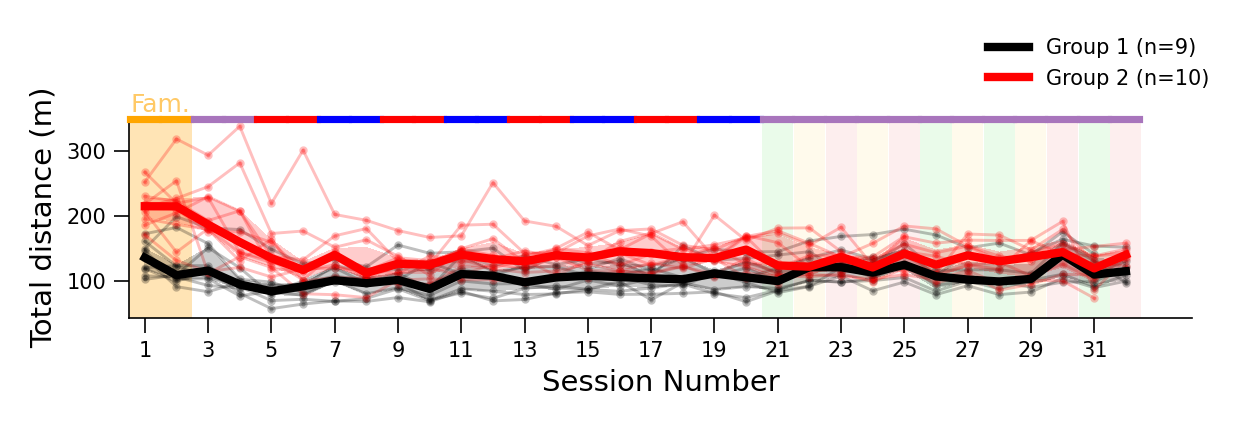

In [9]:
fig = plt.figure(figsize=(cm2inch(12), cm2inch(15)), dpi=300, constrained_layout=False, facecolor='w')
gs = fig.add_gridspec(5, 1, hspace=0.45)

row1 = gs[4].subgridspec(1, 1)
ax_1 = plt.subplot(row1[0, 0])

plot_learning_curves_two_groups(
    mouse_metric_persession=total_distance_m,
    ax=ax_1,
    group1_mice=GROUP1_ANIMALS,
    group2_mice=GROUP2_ANIMALS,
    group1_label='Group 1',
    group2_label='Group 2',
    group1_color='black',
    group2_color='red',
    ylabel='Total distance (m)',
    show_xlabel=True,
    tick_interval=2,
    index_offset=0,
    xlim=[0.5, None],
    show_fam=True,
    legend_loc=(0.8, 1.1)
)

fig.tight_layout()
plt.subplots_adjust(left=0.15)
plt.show()


/tmp/ipykernel_10505/3720165933.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


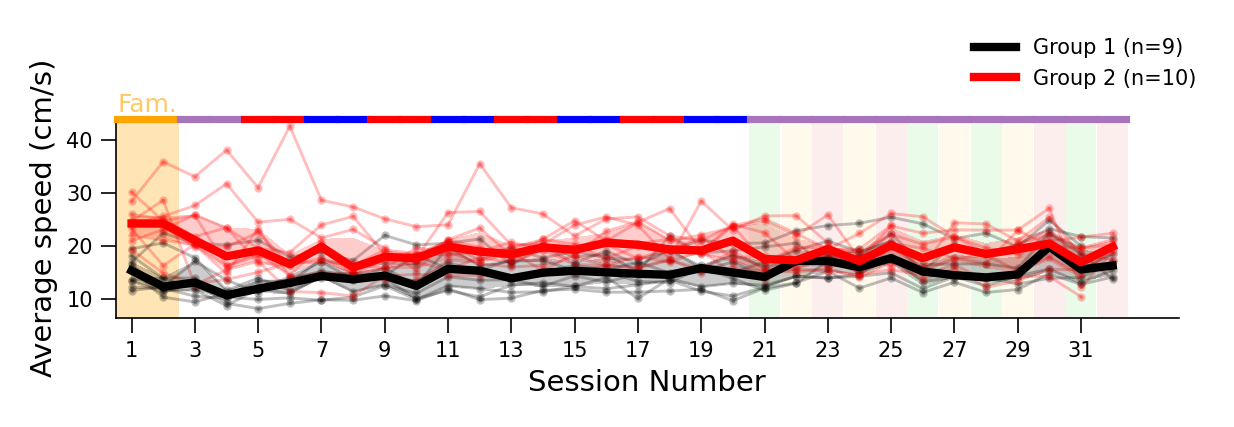

In [10]:
fig = plt.figure(figsize=(cm2inch(12), cm2inch(15)), dpi=300, constrained_layout=False, facecolor='w')
gs = fig.add_gridspec(5, 1, hspace=0.45)

row1 = gs[4].subgridspec(1, 1)
ax_1 = plt.subplot(row1[0, 0])

plot_learning_curves_two_groups(
    mouse_metric_persession=average_speeds,
    ax=ax_1,
    group1_mice=GROUP1_ANIMALS,
    group2_mice=GROUP2_ANIMALS,
    group1_label='Group 1',
    group2_label='Group 2',
    group1_color='black',
    group2_color='red',
    ylabel='Average speed (cm/s)',
    show_xlabel=True,
    tick_interval=2,
    index_offset=0,
    xlim=[0.5, None],
    show_fam=True,
    legend_loc=(0.8, 1.1)
)

fig.tight_layout()
plt.subplots_adjust(left=0.15)
plt.show()


### Time spent in zones 
Function(s)

In [11]:
def calculate_time_in_zones(folder_path_mouse_to_analyse, session_to_analyse, border_zone, trapeze_width, time_start=None, time_end=None):

    """Calculate how much time the mouse spends in border, trapeze, and interior zones.
    
    Parameters:
    folder_path_mouse_to_analyse : str or path-like. Path to the mouse folder containing the processed session.
    session_to_analyse : str. Session folder name.
    border_zone : list. Four border polygons expressed as coordinate arrays.
    trapeze_width : float. Width used to generate trapeze polygons around each tower.
    time_start : float or None, default=None. Optional start time for the analysis window.
    time_end : float or None, default=None. Optional end time for the analysis window.

    Returns:
    tuple. Time spent in each zone and associated percentages, as returned by the existing notebook logic."""

    pickle_file_path = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, session_to_analyse + '_basic_processing_output.pickle')

    towers_coordinates = get_trapeze_and_tower_data(folder_path_mouse_to_analyse, session_to_analyse)[1]

    with open(pickle_file_path, 'rb') as f:
        session_data = pickle.load(f)

    smoothed_xpositions_cm = session_data['positions'][0]
    smoothed_ypositions_cm = session_data['positions'][1]
    times_videoFrames = session_data['timeofframes']

    all_trapezes_coordinates_cm = generate_trapeze_and_tower_coordinates(towers_coordinates, trapeze_width)[0]

    if time_start is None:
        time_start = times_videoFrames[0]
    if time_end is None:
        time_end = times_videoFrames[-1]

    start_idx = np.searchsorted(times_videoFrames, time_start)
    end_idx = np.searchsorted(times_videoFrames, time_end)

    selected_xpositions = smoothed_xpositions_cm[start_idx:end_idx]
    selected_ypositions = smoothed_ypositions_cm[start_idx:end_idx]
    selected_time = times_videoFrames[start_idx:end_idx]

    border_polygons = [
        mpath.Path(border_zone[0]),
        mpath.Path(border_zone[1]),
        mpath.Path(border_zone[2]),
        mpath.Path(border_zone[3])
    ]

    trapeze_polygons = []
    for tower, trapezes in all_trapezes_coordinates_cm.items():
        for trapeze, coords in trapezes.items():
            trapeze_polygons.append(mpath.Path(coords))

    inner_setup_size = (10, 9.5, 84, 83)
    interior_polygon = mpath.Path([
        (inner_setup_size[0], inner_setup_size[1]),
        (inner_setup_size[0], inner_setup_size[3]),
        (inner_setup_size[2], inner_setup_size[3]),
        (inner_setup_size[2], inner_setup_size[1])
    ])

    time_in_border = 0
    time_in_trapeze = 0
    time_in_interior = 0

    for i in range(len(selected_xpositions) - 1):
        point_start = np.array([selected_xpositions[i], selected_ypositions[i]])
        dt = selected_time[i+1] - selected_time[i]

        if any(polygon.contains_point(point_start) for polygon in border_polygons):
            time_in_border += dt
        elif any(polygon.contains_point(point_start) for polygon in trapeze_polygons):
            time_in_trapeze += dt
        elif interior_polygon.contains_point(point_start):
            time_in_interior += dt

    time_spent_in_zones = {
        'border': round(time_in_border, 2),
        'trapeze': round(time_in_trapeze, 2),
        'interior': round(time_in_interior, 2)
    }

    return time_spent_in_zones


Data extraction

In [56]:
# Choose start and end times (in seconds) for the trajectory windows.
time_start_start = 15
time_end_start = 195
time_start_end = 540
time_end_end = 720

mouse_timediff_trapezevsborder = {mouse: [] for mouse in mice_to_analyse}
mouse_timediff_trapezevsborder_start = {mouse: [] for mouse in mice_to_analyse}
mouse_timediff_trapezevsborder_end = {mouse: [] for mouse in mice_to_analyse}

for mouse in mice_to_analyse:

    folder_path_mouse_to_analyse = os.path.join(path_to_data_folder, mouse)

    sessions_to_analyse = sorted([
        name for name in os.listdir(folder_path_mouse_to_analyse)
        if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
        and name.startswith('MOU')
    ])

    sessions_to_analyse = sessions_to_analyse[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    for sessionindex, session_to_analyse in enumerate(sessions_to_analyse):

        output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(
            folder_path_mouse_to_analyse,
            session_to_analyse,
            output_pickle_filename
        )

        if not os.path.exists(output_pickle_filepath):
            mouse_timediff_trapezevsborder[mouse].append([sessionindex + 1, np.nan])
            mouse_timediff_trapezevsborder_start[mouse].append([sessionindex + 1, np.nan])
            mouse_timediff_trapezevsborder_end[mouse].append([sessionindex + 1, np.nan])
            continue

        # Load the session processing pickle.
        with open(output_pickle_filepath, "rb") as f:
            data = pickle.load(f)

        # Full session values already stored in the pickle.
        time_spentinzones = data["time_in_zones"]

        mouse_timediff_trapezevsborder[mouse].append([
            sessionindex + 1,
            time_spentinzones['trapeze'] - time_spentinzones['border']
        ])

        # Start-of-session time window.
        time_spentinzones_start = calculate_time_in_zones(
            folder_path_mouse_to_analyse,
            session_to_analyse,
            border_zone,
            trapeze_width=trapeze_width,
            time_start=time_start_start,
            time_end=time_end_start
        )

        mouse_timediff_trapezevsborder_start[mouse].append([
            sessionindex + 1,
            time_spentinzones_start['trapeze'] - time_spentinzones_start['border']
        ])

        # End-of-session time window.
        time_spentinzones_end = calculate_time_in_zones(
            folder_path_mouse_to_analyse,
            session_to_analyse,
            border_zone,
            trapeze_width=trapeze_width,
            time_start=time_start_end,
            time_end=time_end_end
        )

        mouse_timediff_trapezevsborder_end[mouse].append([
            sessionindex + 1,
            time_spentinzones_end['trapeze'] - time_spentinzones_end['border']
        ])


Plots

/tmp/ipykernel_11158/1328056.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


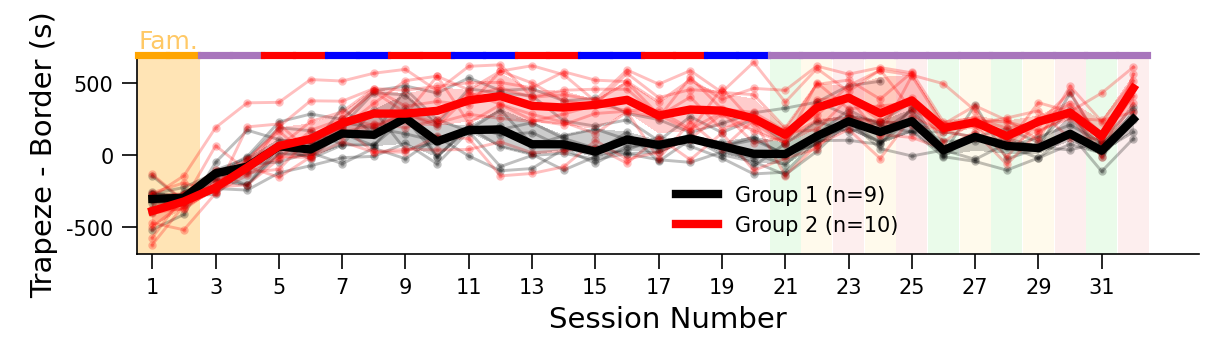

In [85]:
# Entire session

fig = plt.figure(figsize=(cm2inch(12), cm2inch(15)), dpi=300, constrained_layout=False, facecolor='w')
gs = fig.add_gridspec(5, 1, hspace=0.45)

row1 = gs[4].subgridspec(1, 1)
ax_1 = plt.subplot(row1[0, 0])

plot_learning_curves_two_groups(
    mouse_metric_persession=mouse_timediff_trapezevsborder,
    ax=ax_1,
    group1_mice=GROUP1_ANIMALS,
    group2_mice=GROUP2_ANIMALS,
    group1_label='Group 1',
    group2_label='Group 2',
    group1_color='black',
    group2_color='red',
    ylabel='Trapeze - Border (s)',
    show_xlabel=True,
    tick_interval=2,
    index_offset=0,
    xlim=[0.5, None],
    show_fam=True,
    legend_loc=(0.5, 0.05)
)

fig.tight_layout()
plt.subplots_adjust(left=0.15)
plt.show()


/tmp/ipykernel_11158/1487057769.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


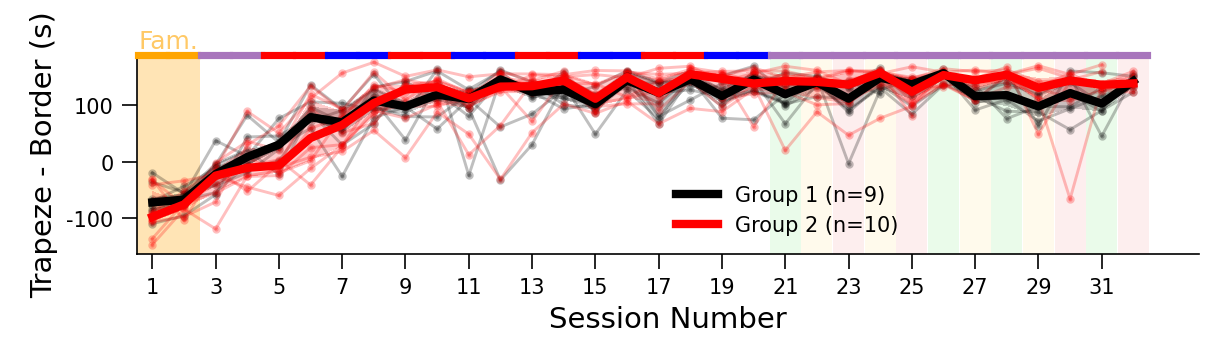

In [86]:
# Beginning of session

fig = plt.figure(figsize=(cm2inch(12), cm2inch(15)), dpi=300, constrained_layout=False, facecolor='w')
gs = fig.add_gridspec(5, 1, hspace=0.45)

row1 = gs[4].subgridspec(1, 1)
ax_1 = plt.subplot(row1[0, 0])

plot_learning_curves_two_groups(
    mouse_metric_persession=mouse_timediff_trapezevsborder_start,
    ax=ax_1,
    group1_mice=GROUP1_ANIMALS,
    group2_mice=GROUP2_ANIMALS,
    group1_label='Group 1',
    group2_label='Group 2',
    group1_color='black',
    group2_color='red',
    ylabel='Trapeze - Border (s)',
    show_xlabel=True,
    tick_interval=2,
    index_offset=0,
    xlim=[0.5, None],
    show_fam=True,
    legend_loc=(0.5, 0.05)
)

fig.tight_layout()
plt.subplots_adjust(left=0.15)
plt.show()


/tmp/ipykernel_11158/3441654786.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


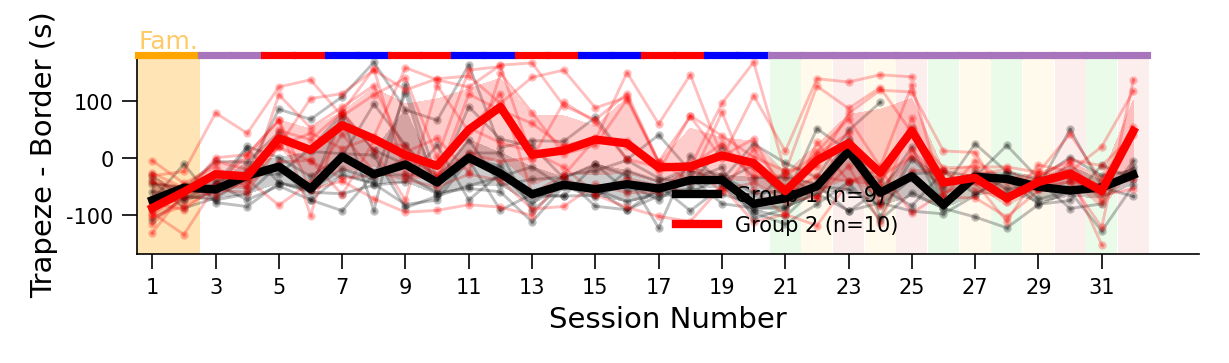

In [87]:
# End of session

fig = plt.figure(figsize=(cm2inch(12), cm2inch(15)), dpi=300, constrained_layout=False, facecolor='w')
gs = fig.add_gridspec(5, 1, hspace=0.45)

row1 = gs[4].subgridspec(1, 1)
ax_1 = plt.subplot(row1[0, 0])

plot_learning_curves_two_groups(
    mouse_metric_persession=mouse_timediff_trapezevsborder_end,
    ax=ax_1,
    group1_mice=GROUP1_ANIMALS,
    group2_mice=GROUP2_ANIMALS,
    group1_label='Group 1',
    group2_label='Group 2',
    group1_color='black',
    group2_color='red',
    ylabel='Trapeze - Border (s)',
    show_xlabel=True,
    tick_interval=2,
    index_offset=0,
    xlim=[0.5, None],
    show_fam=True,
    legend_loc=(0.5, 0.05)
)

fig.tight_layout()
plt.subplots_adjust(left=0.15)
plt.show()


### Exploitation score

Function(s)

In [12]:
def order_runs(all_epochs):
    """Collect and chronologically order all movement epochs except immobility.
    
    Parameters:
    all_epochs : dict. Dictionary of epoch categories. Each value is expected to be a list of epoch records.
    
    Returns: tuple[list, list]. ordered_all_runs contains epoch records sorted by start frame. ordered_all_runs_frames contains the corresponding frame intervals sorted the same way."""

    ordered_all_runs = []
    ordered_all_runs_frames = []

    for k in all_epochs.keys():
        if k != 'immobility':
            for i in range(len(all_epochs[k])):
                ordered_all_runs.append(all_epochs[k][i])
                ordered_all_runs_frames.append(all_epochs[k][i][0])

    ordered_all_runs_frames = sorted(ordered_all_runs_frames, key=lambda x: x[0])
    ordered_all_runs = sorted(ordered_all_runs, key=lambda x: x[0])

    return ordered_all_runs, ordered_all_runs_frames

def define_visits(all_epochs):
    """Group consecutive tower turns into visits using processed epoch data.
    
    Parameters:
    all_epochs : dict. Processed epoch dictionary containing at least the run_around_tower category.
    
    Returns:
    list[dict]. Visit dictionaries summarizing sequences of turns around the same patch/tower."""

    visits = []
    n = -1

    runs_around_tower = all_epochs['run_around_tower']

    temp_all_epochs = all_epochs.copy()
    temp_all_epochs['run_around_tower'] = runs_around_tower

    ordered_all_runs, ordered_all_runs_frames = order_runs(temp_all_epochs)

    for i, run_around_tower in enumerate(runs_around_tower):
        is_good_turn = run_around_tower[3]['Rewarded']
        max_rewards = run_around_tower[3]['max_rewards']

        ordered_idx = ordered_all_runs_frames.index(run_around_tower[0])

        departure, arrival = (
            [ordered_all_runs[ordered_idx - 1][1][0], ordered_all_runs[ordered_idx - 1][2][0]]
            if ordered_idx != 0 else ['', '']
        )

        previous_run_not_a_turn = (departure != arrival) or len(visits) == 0
        previous_run_started_elsewhere = (
            ordered_all_runs[ordered_idx - 1][1][0] != ordered_all_runs[ordered_idx][1][0]
        ) if ordered_idx != 0 else True

        if previous_run_not_a_turn or previous_run_started_elsewhere:
            n += 1
            visits.append({})

            visits[n]['turns'] = 1
            visits[n]['rewarded_turns'] = int(is_good_turn)
            visits[n]['max_reward'] = max_rewards
            visits[n]['patch'] = run_around_tower[1][0]
            visits[n]['visit_time'] = run_around_tower[4]['epoch_time']
            visits[n]['turns_time'] = [run_around_tower[4]['epoch_time']]
            visits[n]['turns_duration'] = [run_around_tower[4]['epoch_duration']]
        else:
            visits[n]['rewarded_turns'] += int(is_good_turn)
            visits[n]['turns'] += 1
            visits[n]['turns_time'] = visits[n]['turns_time'] + [run_around_tower[4]['epoch_time']]
            visits[n]['turns_duration'] = visits[n]['turns_duration'] + [run_around_tower[4]['epoch_duration']]

    return visits

def define_csv_visits(df):
    """Convert visit information from the CSV/turns dataframe into visit-level records.
    
    Parameters:
    turns_df : pandas.DataFrame. Session turns dataframe loaded from the behavioral CSV files.
    
    Returns:
    list[dict]. Visit dictionaries reconstructed from the CSV rows."""
    n = -1
    visits = []

    for i in range(len(df)):
        previous_transition_in_other_patch = df.currentPatch[i] != df.currentPatch[i - 1] if i > 0 else True
        previous_cumulated_rewards_higher = df.nberOfConsecRewards[i] < df.nberOfConsecRewards[i - 1] if i > 0 else True
        previous_cumulated_rewards_zero = df.nberOfConsecRewards[i - 1] == 0 if i > 0 else True
        left_tower_after_previous_transition = previous_cumulated_rewards_higher and previous_cumulated_rewards_zero

        if previous_transition_in_other_patch or left_tower_after_previous_transition:
            n += 1
            visits.append({})

            visits[n]['transitions'] = 1
            visits[n]['rewarded_transitions'] = int(df.Rewarded[i])
            visits[n]['cumulated_rewards'] = df.nberOfConsecRewards[i]
            visits[n]['max_reward'] = df.maxNberOfConsecRewards[i]
            visits[n]['patch'] = df.currentPatch[i]
            visits[n]['first_transition_time'] = df.time[i]
            visits[n]['transitions_time'] = [df.time[i]]
            visits[n]['transitions_reward_status'] = [df.Rewarded[i]]
        else:
            visits[n]['transitions'] += 1
            visits[n]['rewarded_transitions'] += int(df.Rewarded[i])
            visits[n]['cumulated_rewards'] = df.nberOfConsecRewards[i]
            visits[n]['transitions_time'] = visits[n]['transitions_time'] + [df.time[i]]
            visits[n]['transitions_reward_status'] = visits[n]['transitions_reward_status'] + [df.Rewarded[i]]

    return visits

def find_rewarded_csv_visit(visits):
    """Find the CSV-derived visit that corresponds to a given pickle-derived visit.
    
    Parameters:
    pickle_visit : dict. Visit reconstructed from processed epoch data.
    csv_visits : list[dict]. Candidate visits reconstructed from the CSV/turns dataframe.
    
    Returns:
    dict or None. Matching CSV visit when one can be identified; otherwise ``None``."""

    return [visit for visit in visits if visit['rewarded_transitions'] > 0]

def check_is_transition_in_pickle_visit(csv_visit, pickle_visit):
    """Determine whether a pickle-derived visit contains a transition between patches.
    
    Parameters:
    pickle_visit : dict. Visit dictionary reconstructed from processed epochs.
    
    Returns:
    bool. True if the visit is marked as, or can be inferred to include, a transition; otherwise False."""
    for transition_time in csv_visit['transitions_time']:
        for i in range(len(pickle_visit['turns_time'])):
            turn_start_time = pickle_visit['turns_time'][i]
            turn_end_time = pickle_visit['turns_time'][i] + pickle_visit['turns_duration'][i]

            if turn_start_time <= transition_time <= turn_end_time:
                return True

    return False

def pair_csv_pickle_visits(csv_visits, pickle_visits):

    """Pair CSV-derived visits with pickle-derived visits for the same session.
    
    Parameters:
    csv_visits : list[dict]. Visits reconstructed from the CSV/turns dataframe.
    pickle_visits : list[dict]. Visits reconstructed from processed epoch data.
    
    Returns:
    list[tuple] or list[dict]. Paired visit records following the structure defined by the notebook logic."""

    kept_visits = []

    pickle_visits_temp = copy.deepcopy(pickle_visits)
    csv_visits_temp = copy.deepcopy(csv_visits)

    while len(pickle_visits_temp) > 0:
        pickle_visit = pickle_visits_temp[0]

        for i, csv_visit in enumerate(csv_visits_temp):
            is_transition_in_pickle_visit = check_is_transition_in_pickle_visit(csv_visit, pickle_visit)

            if is_transition_in_pickle_visit:
                kept_visits.append(csv_visit)
                pickle_visits_temp.pop(0)
                break

    return kept_visits


Data extraction

In [13]:
# Compute the mean number of transitions per rewarded visit for each mouse and session.

mouse_mean_turns_per_rewarded_visit = {mouse: [] for mouse in mice_to_analyse}

for mouse in mice_to_analyse:
    folder_path_mouse_to_analyse = os.path.join(path_to_data_folder, mouse)

    sessions_to_analyse = sorted([
        name for name in os.listdir(folder_path_mouse_to_analyse)
        if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
        and name.startswith('MOU')
    ])

    sessions_to_analyse = sessions_to_analyse[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    print(f'Mouse {mouse}. {len(sessions_to_analyse)} sessions')

    for session_index, session_to_analyse in enumerate(sessions_to_analyse):
        output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(
            folder_path_mouse_to_analyse,
            session_to_analyse,
            output_pickle_filename
        )

        turns_csv_path = os.path.join(
            folder_path_mouse_to_analyse,
            session_to_analyse,
            session_to_analyse + '_turnsinfo.csv'
        )

        if not os.path.exists(output_pickle_filepath) or not os.path.exists(turns_csv_path):
            mouse_mean_turns_per_rewarded_visit[mouse].append([session_index + 1, np.nan])
            continue

        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        turns_df = pd.read_csv(turns_csv_path)

        # Build visit lists from both data sources before matching rewarded visits.
        pickle_visits = define_visits(session_data['all_epochs'])
        rewarded_pickle_visits = [v for v in pickle_visits if v['rewarded_turns'] > 0]

        csv_visits = define_csv_visits(turns_df)
        rewarded_csv_visits = find_rewarded_csv_visit(csv_visits)
        paired_rewarded_csv_visits = pair_csv_pickle_visits(rewarded_csv_visits, rewarded_pickle_visits)

        # Count valid transitions associated with each matched rewarded visit.
        transitions_list = []

        for csv_visit, pickle_visit in zip(paired_rewarded_csv_visits, rewarded_pickle_visits):
            transitions = csv_visit['transitions']

            if csv_visit['transitions_time'][-1] > (
                pickle_visit['turns_time'][-1] + pickle_visit['turns_duration'][-1]
            ):
                transitions -= 1

            transitions_list.append(transitions)

        mean_turns_per_rewarded_visit = np.nanmean(transitions_list) if len(transitions_list) > 0 else np.nan

        if session_index >= 2:
            mouse_mean_turns_per_rewarded_visit[mouse].append([session_index + 1, mean_turns_per_rewarded_visit])
        else:
            mouse_mean_turns_per_rewarded_visit[mouse].append([session_index + 1, np.nan])


Mouse MOUB6JRj749. 32 sessions
Mouse MOUB6JRj750. 32 sessions
Mouse MOUB6JRj752. 32 sessions
Mouse MOU5468. 31 sessions
Mouse MOU5500. 25 sessions
Mouse MOUB6JRj755. 32 sessions
Mouse MOU5289. 32 sessions
Mouse MOU5415. 32 sessions
Mouse MOU5471. 31 sessions
Mouse MOU5496. 25 sessions
Mouse MOUB6JRj748. 32 sessions
Mouse MOUB6JRj751. 32 sessions
Mouse MOU5465. 31 sessions
Mouse MOU5501. 24 sessions
Mouse MOUB6JRj753. 32 sessions
Mouse MOUB6JRj756. 32 sessions
Mouse MOU5291. 32 sessions
Mouse MOU5413. 32 sessions
Mouse MOU5498. 25 sessions


/tmp/ipykernel_10505/566933218.py:43: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


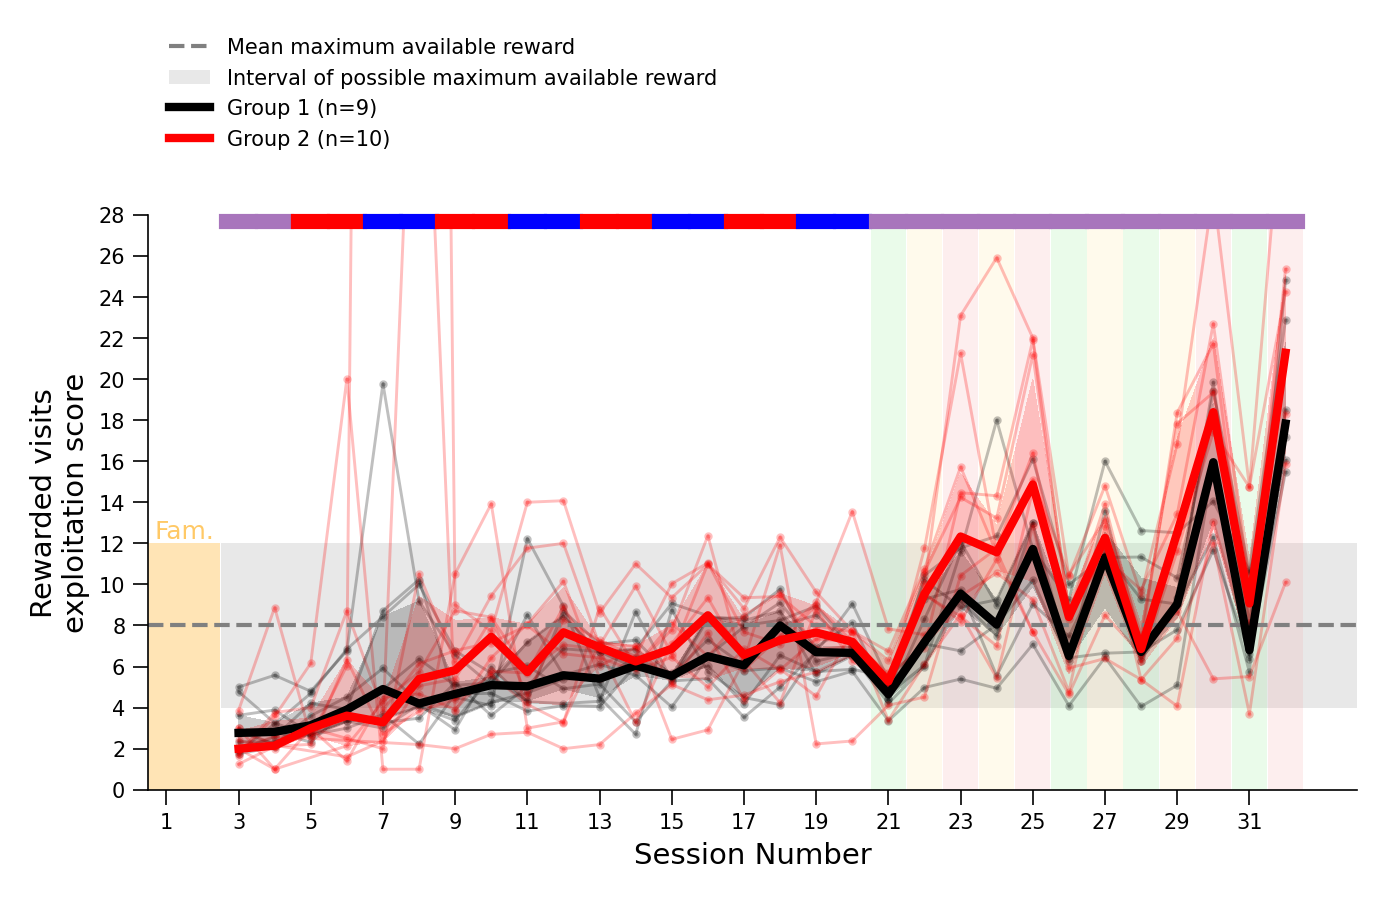

In [14]:
fig = plt.figure(figsize=(cm2inch(12), cm2inch(8)), dpi=300, facecolor='w')
ax = fig.add_subplot(111)

ax.axhline(
    8,
    linestyle='--',
    color='gray',
    linewidth=1,
    label='Mean maximum available reward'
)

ax.axhspan(
    4, 12,
    xmin=0.06,
    color='lightgray',
    alpha=0.5,
    linewidth=0,
    zorder=-np.inf,
    label='Interval of possible maximum available reward'
)

plot_learning_curves_two_groups(
    mouse_metric_persession=mouse_mean_turns_per_rewarded_visit,
    ax=ax,
    group1_mice=GROUP1_ANIMALS,
    group2_mice=GROUP2_ANIMALS,
    group1_label='Group 1', # Update this label to rename the group.
    group2_label='Group 2', # Update this label to rename the group.
    group1_color='black',
    group2_color='red',
    ylabel='Rewarded visits\nexploitation score',
    show_xlabel=True,
    tick_interval=2,
    index_offset=0,
    xlim=[0.5, None],
    ylim=[0, 12],
    show_fam=True,
    legend_loc=(0.01, 1.1)
)

ax.set_yticks(range(0, 30, 2))

fig.tight_layout()
plt.show()


### Fréchet distance
Function(s)

In [15]:
def towers_coordinates_as_dictionnary(towers_coordinates_cm):
    """Convert tower corner coordinates into a named-corner dictionary.
    
    Parameters:
    towers_coordinates_cm : dict. Mapping from tower identifier to an ordered list of four corner coordinates in centimeters.
    
    Returns:
    dict. Nested dictionary ``{tower: {corner_name: coordinate}}`` with corner names ``"NW"``, ``"NE"``, ``"SE"``, and ``"SW"``."""

    towers_coordinates_as_dict = {}
    corner_names = ['NW', 'NE', 'SE', 'SW']

    for tower, coordinates in towers_coordinates_cm.items():
        towers_coordinates_as_dict[tower] = {
            corner_names[i]: coord for i, coord in enumerate(coordinates)
        }

    return towers_coordinates_as_dict

def get_tower_and_corner(run_around_tower):
    """Extract the tower and corner crossed by a quarter-turn epoch.
    
    Parameters:
    run_around_tower : list-like. Quarter-turn epoch record. The function expects tower/trapeze information at indices 1 and 2.
    
    Returns:
    tuple[str, str or None]. Tower name and corner label."""

    tower_name = run_around_tower[1][0]
    start_trapeze = run_around_tower[1][1]
    end_trapeze = run_around_tower[2][1]

    if start_trapeze == 'W' and end_trapeze == 'S':
        corner = 'SW'
    elif start_trapeze == 'S' and end_trapeze == 'E':
        corner = 'SE'
    elif start_trapeze == 'E' and end_trapeze == 'N':
        corner = 'NE'
    elif start_trapeze == 'N' and end_trapeze == 'W':
        corner = 'NW'
    elif start_trapeze == 'W' and end_trapeze == 'N':
        corner = 'NW'
    elif start_trapeze == 'N' and end_trapeze == 'E':
        corner = 'NE'
    elif start_trapeze == 'E' and end_trapeze == 'S':
        corner = 'SE'
    elif start_trapeze == 'S' and end_trapeze == 'W':
        corner = 'SW'
    else:
        corner = None

    return tower_name, corner

def rotate_sw_trajectory_90_ccw(trajectory):
    """Rotate an SW-aligned trajectory by 90 degrees counterclockwise.
    
    Parameters:
    trajectory : numpy.ndarray. Two-row array of x/y coordinates with shape (2, n_points).
    
    Returns:
    numpy.ndarray. Rotated trajectory with the same shape as the input."""

    rotation_matrix = np.array([[0, -1], [1, 0]])
    return rotation_matrix @ trajectory

def rotate_nw_trajectory_180_ccw(trajectory):
    """Rotate an NW-aligned trajectory by 180 degrees.
    
    Parameters!
    trajectory : numpy.ndarray. Two-row coordinate array with shape (2, n_points).
    
    Returns: numpy.ndarray"""
    return -trajectory

def rotate_ne_trajectory_270_ccw(trajectory):
    """Rotate an NE-aligned trajectory by 270 degrees counterclockwise.
    
    Parameters:
    trajectory : numpy.ndarray. Two-row coordinate array with shape (2, n_points).
    
    Returns:
    numpy.ndarray. Rotated trajectory with the same shape as the input."""

    rotation_matrix = np.array([[0, 1], [-1, 0]])
    return rotation_matrix @ trajectory

def align_cw_ccw_trajectory(trajectory, direction, flip_axis='x'):
    """Mirror counterclockwise trajectories into the clockwise reference frame.
    
    Parameters:
    trajectory : numpy.ndarray
        Two-row coordinate array with shape ``(2, n_points)``.
    direction : str
        Turn direction, typically ``"CW"`` or ``"CCW"``. Only CCW trajectories are mirrored.
    flip_axis : {"x", "y"}, default="x"
        Coordinate axis to flip when ``direction == "CCW"``.
    
    Returns:
    numpy.ndarray. Copy of the input trajectory, mirrored when requested.
    
    Raises:
    ValueError. If flip_axis is not "x" or "y".
    """
    aligned_trajectory = trajectory.copy()

    if direction == 'CCW':
        if flip_axis == 'x':
            aligned_trajectory[0, :] = -aligned_trajectory[0, :]
        elif flip_axis == 'y':
            aligned_trajectory[1, :] = -aligned_trajectory[1, :]
        else:
            raise ValueError("flip_axis must be 'x' or 'y'")

    return aligned_trajectory

def compute_frechet_distances(runs_list):
    """Compute all pairwise Fréchet distances between trajectories.
    
    Parameters:
    runs_list: list[numpy.ndarray]. List of trajectories, each stored as a (2, n_points) array.
    
    Returns:
    list[float].Fréchet distance for each unique trajectory pair (i, j) with j > i. Returns an empty list when fewer than two trajectories are provided."""

    frechet_distances_list = []

    for i in range(len(runs_list)):
        traj_points_a = np.transpose(runs_list[i])

        for j in range(i + 1, len(runs_list)):
            traj_points_b = np.transpose(runs_list[j])
            frechet_distance = sm.frechet_dist(traj_points_a, traj_points_b)
            frechet_distances_list.append(frechet_distance)

    return frechet_distances_list

def align_qt_trajectory(this_trajectory, tower_name, corner, direction,
                        towers_coordinates_as_dict,
                        align_direction=False, flip_axis='x'):
    """Translate, rotate, and optionally mirror one quarter-turn trajectory into a common frame.
    
    Parameters:
    this_trajectory : numpy.ndarray. Raw trajectory as a (2, n_points) x/y coordinate array.
    tower_name : str. Tower identifier for the turn.
    corner : str. Corner label associated with the turn: "SW", "NW", "NE", or "SE".
    direction : str. Turn direction, typically "CW" or "CCW".
    towers_coordinates_as_dict : dict. Nested dictionary mapping tower names and corner labels to x/y coordinates.
    align_direction : bool, default=False. If True, mirror CCW trajectories so CW and CCW turns share the same direction reference frame.
    flip_axis : {"x", "y"}, default="x". Axis used for optional direction alignment.
    
    Returns:
    numpy.ndarray. Aligned trajectory. The original input array is not modified."""

    aligned_trajectory = this_trajectory.copy()

    this_corner_coordinates = towers_coordinates_as_dict[tower_name][corner]

    # Translate the trajectory so the selected tower corner is at the origin.
    aligned_trajectory[0, :] -= this_corner_coordinates[0]
    aligned_trajectory[1, :] -= this_corner_coordinates[1]

    # Rotate the trajectory according to the starting corner.
    if corner == 'SW':
        aligned_trajectory = rotate_sw_trajectory_90_ccw(aligned_trajectory)
    elif corner == 'NW':
        aligned_trajectory = rotate_nw_trajectory_180_ccw(aligned_trajectory)
    elif corner == 'NE':
        aligned_trajectory = rotate_ne_trajectory_270_ccw(aligned_trajectory)
    # If corner == 'SE', the trajectory is already in the reference orientation.

    # Optionally mirror CCW trajectories onto the CW reference frame.
    if align_direction:
        aligned_trajectory = align_cw_ccw_trajectory(aligned_trajectory, direction=direction, flip_axis=flip_axis)

    return aligned_trajectory

def compute_session_frechet(trajectories, minimum_number_of_qts=5):
    """Compute a session-level median Fréchet distance when enough trajectories are available.
    
    Parameters:
    trajectories : list[numpy.ndarray]. Trajectories to compare.
    minimum_number_of_qts : int, default=5. Minimum number of quarter-turn trajectories required before computing pairwise distances.
    
    Returns:
    float. Median pairwise Fréchet distance, ignoring NaNs, or ``np.nan`` if fewer than ``minimum_number_of_qts`` trajectories are available."""

    if len(trajectories) >= minimum_number_of_qts:
        return np.nanmedian(compute_frechet_distances(trajectories))
    return np.nan

def compute_frechet_for_one_session(folder_path_mouse_to_process, session_to_process, minimum_number_of_qts=5):

    """Compute Fréchet-distance metrics for one processed behavioral session.
    
    Parameters:
    folder_path_mouse_to_process : str or path-like. Path to the mouse folder containing the session folder.
    session_to_process : str. Name of the session folder.
    minimum_number_of_qts : int, default=5. Minimum number of quarter-turn trajectories required for each metric. Categories with fewer trajectories return ``np.nan``.
    
    Returns:
    dict. Dictionary with median Fréchet distances for rewarded, unrewarded, CW, CCW, CW rewarded, CCW rewarded, CW unrewarded, and CCW unrewarded turns. 
    All values are np.nan when the processed-session pickle file is missing."""

    output_pickle_filename = f"{session_to_process}_basic_processing_output.pickle"
    output_pickle_filepath = os.path.join(folder_path_mouse_to_process, session_to_process, output_pickle_filenam)

    if not os.path.exists(output_pickle_filepath):
        return {
            "rewarded_frechet": np.nan,
            "unrewarded_frechet": np.nan,
            "cw_frechet": np.nan,
            "ccw_frechet": np.nan,
            "cw_rew_frechet": np.nan,
            "ccw_rew_frechet": np.nan,
            "cw_unrew_frechet": np.nan,
            "ccw_unrew_frechet": np.nan,
        }

    with open(output_pickle_filepath, "rb") as file:
        session_data = pickle.load(file)

    runs_around_tower = filter_qts(copy.deepcopy(session_data["all_epochs"]["run_around_tower"]))
    positions = np.array(session_data["positions"])

    towers_coordinates_cm = session_data["towers_coordinates_cm"]
    towers_coordinates_as_dict = towers_coordinates_as_dictionnary(towers_coordinates_cm)

    rewarded_trajectories = []
    unrewarded_trajectories = []
    cw_trajectories = []
    ccw_trajectories = []
    cw_rewarded_trajectories = []
    ccw_rewarded_trajectories = []
    cw_unrewarded_trajectories = []
    ccw_unrewarded_trajectories = []

    for run_around_tower in runs_around_tower:

        if run_around_tower[3]["num_trapezeswitch"] != 1:
            continue

        rewarded = run_around_tower[3]["Rewarded"]
        direction = run_around_tower[3]["direction"]

        if direction not in ["CW", "CCW"]:
            continue

        tower_name, corner = get_tower_and_corner(run_around_tower)

        if tower_name not in towers_coordinates_as_dict:
            continue

        if corner not in towers_coordinates_as_dict[tower_name]:
            continue

        start_idx, end_idx = run_around_tower[0]
        this_trajectory = positions[:, start_idx:end_idx].copy()

        aligned_for_reward = align_qt_trajectory(
            this_trajectory=this_trajectory,
            tower_name=tower_name,
            corner=corner,
            direction=direction,
            towers_coordinates_as_dict=towers_coordinates_as_dict,
            align_direction=True,
            flip_axis="x"
        )

        aligned_for_direction = align_qt_trajectory(
            this_trajectory=this_trajectory,
            tower_name=tower_name,
            corner=corner,
            direction=direction,
            towers_coordinates_as_dict=towers_coordinates_as_dict,
            align_direction=False
        )

        if rewarded:
            rewarded_trajectories.append(aligned_for_reward)
        else:
            unrewarded_trajectories.append(aligned_for_reward)

        if direction == "CW":
            cw_trajectories.append(aligned_for_direction)
            if rewarded:
                cw_rewarded_trajectories.append(aligned_for_direction)
            else:
                cw_unrewarded_trajectories.append(aligned_for_direction)

        elif direction == "CCW":
            ccw_trajectories.append(aligned_for_direction)
            if rewarded:
                ccw_rewarded_trajectories.append(aligned_for_direction)
            else:
                ccw_unrewarded_trajectories.append(aligned_for_direction)

    frechet_results = {
        "rewarded_frechet": compute_session_frechet(rewarded_trajectories, minimum_number_of_qts),
        "unrewarded_frechet": compute_session_frechet(unrewarded_trajectories, minimum_number_of_qts),
        "cw_frechet": compute_session_frechet(cw_trajectories, minimum_number_of_qts),
        "ccw_frechet": compute_session_frechet(ccw_trajectories, minimum_number_of_qts),
        "cw_rew_frechet": compute_session_frechet(cw_rewarded_trajectories, minimum_number_of_qts),
        "ccw_rew_frechet": compute_session_frechet(ccw_rewarded_trajectories, minimum_number_of_qts),
        "cw_unrew_frechet": compute_session_frechet(cw_unrewarded_trajectories, minimum_number_of_qts),
        "ccw_unrew_frechet": compute_session_frechet(ccw_unrewarded_trajectories, minimum_number_of_qts),
    }

    return frechet_results


Data extraction

In [16]:
FRECHET_PICKLE_NAMES = {
    "ccw_unrew_frechet": "ccw_unrew_frechet.pickle",
    "cw_unrew_frechet": "cw_unrew_frechet.pickle",
    "ccw_rew_frechet": "ccw_rew_frechet.pickle",
    "cw_rew_frechet": "cw_rew_frechet.pickle",
    "ccw_frechet": "ccw_frechet.pickle",
    "cw_frechet": "cw_frechet.pickle",
    "unrewarded_frechet": "unrewarded_frechet.pickle",
    "rewarded_frechet": "rewarded_frechet.pickle",
}


In [17]:
# Compute or load cached Fréchet-distance metrics for each mouse and session.

rewarded_turns_frechet_distances_per_session = {mouse: [] for mouse in mice_to_analyse}
unrewarded_turns_frechet_distances_per_session = {mouse: [] for mouse in mice_to_analyse}
cw_turns_frechet_distances_per_session = {mouse: [] for mouse in mice_to_analyse}
ccw_turns_frechet_distances_per_session = {mouse: [] for mouse in mice_to_analyse}
cw_rewarded_frechet_distances_per_session = {mouse: [] for mouse in mice_to_analyse}
ccw_rewarded_frechet_distances_per_session = {mouse: [] for mouse in mice_to_analyse}
cw_unrewarded_frechet_distances_per_session = {mouse: [] for mouse in mice_to_analyse}
ccw_unrewarded_frechet_distances_per_session = {mouse: [] for mouse in mice_to_analyse}

allsessionnumber = list(range(first_and_last_session_indexes[0] + 1,
                              first_and_last_session_indexes[1] + 1))

minimum_number_of_qts = 5

for mouse in mice_to_analyse:

    print(f"Computing/loading Fréchet distances for {mouse}")

    folder_path_mouse_to_process = os.path.join(path_to_data_folder, mouse)

    sessions_to_process = sorted([
        name for name in os.listdir(folder_path_mouse_to_process)
        if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
        and name.startswith("MOU")
    ])

    sessions_to_process = sessions_to_process[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    for session_index, session_to_process in enumerate(sessions_to_process):

        pickle_jar_path = get_pickle_jar_path(folder_path_mouse_to_process, session_to_process)

        # Reuse cached Fréchet metrics when available to avoid recomputing pairwise distances.
        if frechet_pickles_exist(pickle_jar_path, FRECHET_PICKLE_NAMES):
            frechet_results = load_frechet_pickles(pickle_jar_path, FRECHET_PICKLE_NAMES)
            print(f"  Session {session_to_process}: pickles already exist, loading.")
        else:
            print(f"  Session {session_to_process}: pickles do not exist, processing.")
            frechet_results = compute_frechet_for_one_session(
                folder_path_mouse_to_process,
                session_to_process,
                minimum_number_of_qts=minimum_number_of_qts
            )
            save_frechet_pickles(pickle_jar_path, frechet_results, FRECHET_PICKLE_NAMES)
            # print(f"Session {session_to_process}: processed and saved.")

        session_number = allsessionnumber[session_index]

        rewarded_turns_frechet_distances_per_session[mouse].append([session_number, frechet_results["rewarded_frechet"]])
        unrewarded_turns_frechet_distances_per_session[mouse].append([session_number, frechet_results["unrewarded_frechet"]])
        cw_turns_frechet_distances_per_session[mouse].append([session_number, frechet_results["cw_frechet"]])
        ccw_turns_frechet_distances_per_session[mouse].append([session_number, frechet_results["ccw_frechet"]])
        cw_rewarded_frechet_distances_per_session[mouse].append([session_number, frechet_results["cw_rew_frechet"]])
        ccw_rewarded_frechet_distances_per_session[mouse].append([session_number, frechet_results["ccw_rew_frechet"]])
        cw_unrewarded_frechet_distances_per_session[mouse].append([session_number, frechet_results["cw_unrew_frechet"]])
        ccw_unrewarded_frechet_distances_per_session[mouse].append([session_number, frechet_results["ccw_unrew_frechet"]])

    print(f"All {mouse} sessions processed and saved.")


Computing/loading Fréchet distances for MOUB6JRj749
  Session MOUB6JRj749_20260109-1312: pickles already exist, loading.
  Session MOUB6JRj749_20260109-1713: pickles already exist, loading.
  Session MOUB6JRj749_20260113-1138: pickles already exist, loading.
  Session MOUB6JRj749_20260113-1622: pickles already exist, loading.
  Session MOUB6JRj749_20260114-1127: pickles already exist, loading.
  Session MOUB6JRj749_20260114-1626: pickles already exist, loading.
  Session MOUB6JRj749_20260115-1118: pickles already exist, loading.
  Session MOUB6JRj749_20260115-1624: pickles already exist, loading.
  Session MOUB6JRj749_20260116-1130: pickles already exist, loading.
  Session MOUB6JRj749_20260116-1618: pickles already exist, loading.
  Session MOUB6JRj749_20260117-1119: pickles already exist, loading.
  Session MOUB6JRj749_20260117-1558: pickles already exist, loading.
  Session MOUB6JRj749_20260118-1121: pickles already exist, loading.
  Session MOUB6JRj749_20260118-1554: pickles alread

Plot

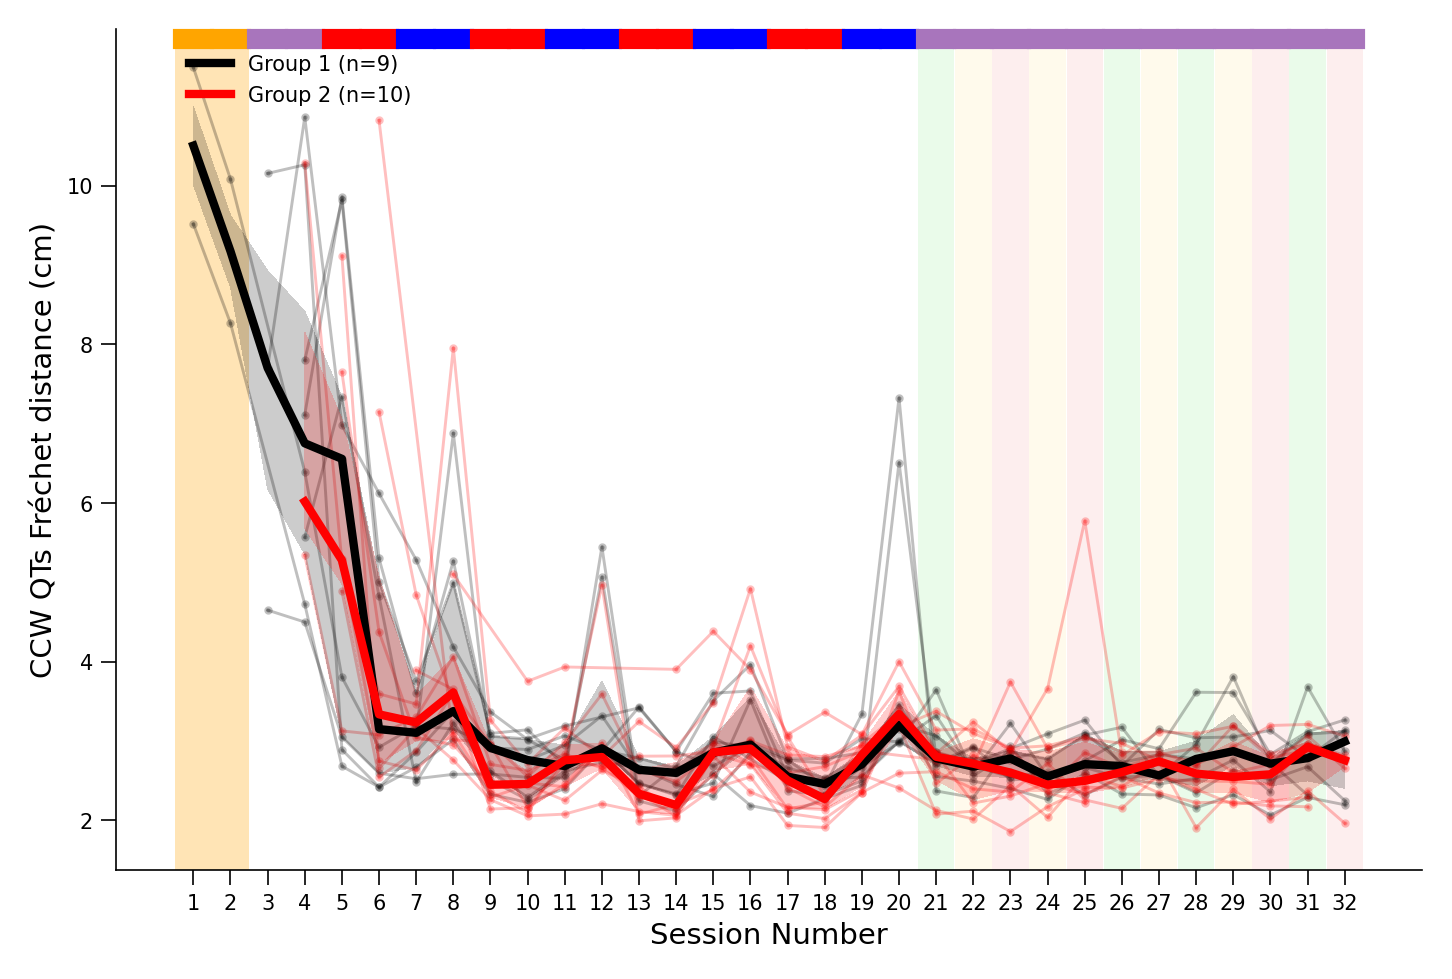

In [18]:
fig = plt.figure(figsize=(cm2inch(12), cm2inch(8)), dpi=300, facecolor='w')
ax = fig.add_subplot(111)

plot_learning_curves_two_groups(
    mouse_metric_persession=ccw_turns_frechet_distances_per_session,
    ax=ax,
    group1_mice=GROUP1_ANIMALS,
    group2_mice=GROUP2_ANIMALS,
    ylabel='CCW QTs Fréchet distance (cm)'
)


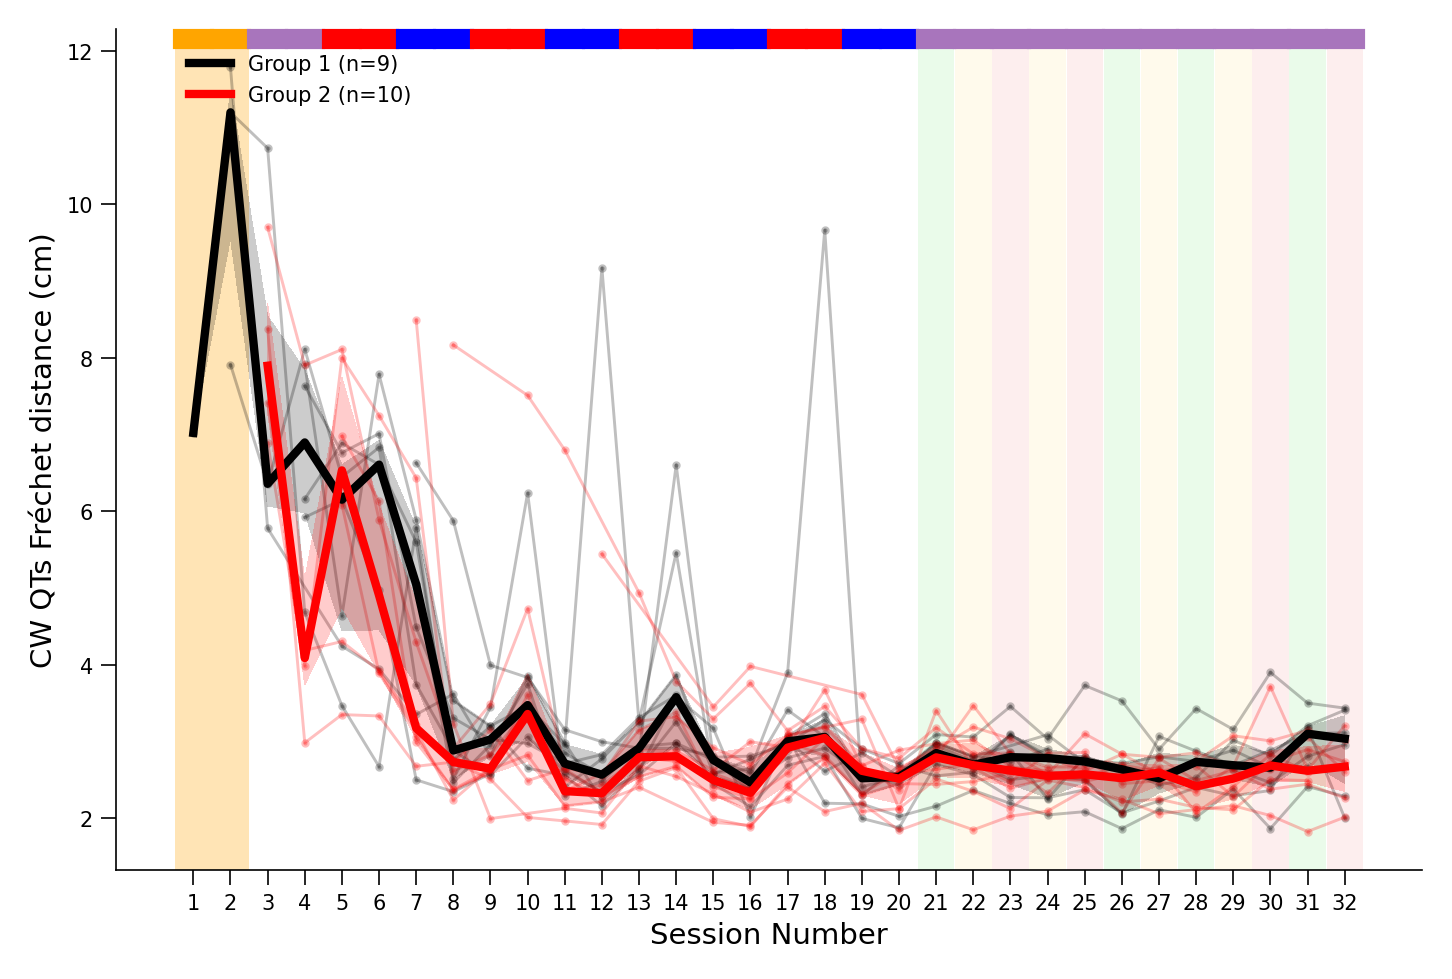

In [19]:
fig = plt.figure(figsize=(cm2inch(12), cm2inch(8)), dpi=300, facecolor='w')
ax = fig.add_subplot(111)

plot_learning_curves_two_groups(
    mouse_metric_persession=cw_turns_frechet_distances_per_session,
    ax=ax,
    group1_mice=GROUP1_ANIMALS,
    group2_mice=GROUP2_ANIMALS,
    ylabel='CW QTs Fréchet distance (cm)'
)


### QTs speed
Data extraction

In [23]:
# Compute median maximum and mean speeds across filtered quarter-turns.

mouse_median_qt_maxspeed_persession = {mouse: [] for mouse in mice_to_analyse}
mouse_median_qt_meanspeed_persession = {mouse: [] for mouse in mice_to_analyse}

mouse_median_cw_qt_maxspeed_persession = {mouse: [] for mouse in mice_to_analyse}
mouse_median_cw_qt_meanspeed_persession = {mouse: [] for mouse in mice_to_analyse}

mouse_median_ccw_qt_maxspeed_persession = {mouse: [] for mouse in mice_to_analyse}
mouse_median_ccw_qt_meanspeed_persession = {mouse: [] for mouse in mice_to_analyse}

mouse_median_rewarded_qt_maxspeed_persession = {mouse: [] for mouse in mice_to_analyse}
mouse_median_rewarded_qt_meanspeed_persession = {mouse: [] for mouse in mice_to_analyse}

mouse_median_unrewarded_qt_maxspeed_persession = {mouse: [] for mouse in mice_to_analyse}
mouse_median_unrewarded_qt_meanspeed_persession = {mouse: [] for mouse in mice_to_analyse}

for mouse in mice_to_analyse:
    folder_path_mouse_to_analyse = os.path.join(path_to_data_folder, mouse)

    sessions_to_analyse = sorted([
        name for name in os.listdir(folder_path_mouse_to_analyse)
        if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
        and name.startswith('MOU')
    ])

    sessions_to_analyse = sessions_to_analyse[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    print(f'Mouse {mouse}. {len(sessions_to_analyse)} sessions')

    for session_index, session_to_analyse in enumerate(sessions_to_analyse):
        output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(
            folder_path_mouse_to_analyse,
            session_to_analyse,
            output_pickle_filename
        )

        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file missing for session {session_to_analyse}, skipping...')
            mouse_median_qt_maxspeed_persession[mouse].append([session_index + 1, np.nan])
            mouse_median_qt_meanspeed_persession[mouse].append([session_index + 1, np.nan])

            mouse_median_cw_qt_maxspeed_persession[mouse].append([session_index + 1, np.nan])
            mouse_median_cw_qt_meanspeed_persession[mouse].append([session_index + 1, np.nan])

            mouse_median_ccw_qt_maxspeed_persession[mouse].append([session_index + 1, np.nan])
            mouse_median_ccw_qt_meanspeed_persession[mouse].append([session_index + 1, np.nan])

            mouse_median_rewarded_qt_maxspeed_persession[mouse].append([session_index + 1, np.nan])
            mouse_median_rewarded_qt_meanspeed_persession[mouse].append([session_index + 1, np.nan])

            mouse_median_unrewarded_qt_maxspeed_persession[mouse].append([session_index + 1, np.nan])
            mouse_median_unrewarded_qt_meanspeed_persession[mouse].append([session_index + 1, np.nan])
            continue

        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        # Use all filtered quarter-turns without separating CW and CCW directions.
        qts = filter_qts(session_data["all_epochs"]["run_around_tower"])

        cw_qts = [qt for qt in qts if qt[3]["direction"] == "CW"]
        ccw_qts = [qt for qt in qts if qt[3]["direction"] == "CCW"]
        rewarded_qts = [qt for qt in qts if qt[3]["Rewarded"]]
        unrewarded_qts = [qt for qt in qts if not qt[3]["Rewarded"]]

        if len(qts) == 0:
            median_qt_maxspeed = np.nan
            median_qt_meanspeed = np.nan
            median_cw_qt_maxspeed = np.nan
            median_cw_qt_meanspeed = np.nan
            median_ccw_qt_maxspeed = np.nan
            median_ccw_qt_meanspeed = np.nan
            median_rewarded_qt_maxspeed = np.nan
            median_rewarded_qt_meanspeed = np.nan
            median_unrewarded_qt_maxspeed = np.nan
            median_unrewarded_qt_meanspeed = np.nan

        else:
            qt_maxspeeds = [qt[4]["epoch_maxspeed"] for qt in qts]
            qt_meanspeeds = [qt[4]["epoch_meanspeed"] for qt in qts]

            cw_qt_maxspeeds = [qt[4]["epoch_maxspeed"] for qt in cw_qts]
            cw_qt_meanspeeds = [qt[4]["epoch_meanspeed"] for qt in cw_qts]

            ccw_qt_maxspeeds = [qt[4]["epoch_maxspeed"] for qt in ccw_qts]
            ccw_qt_meanspeeds = [qt[4]["epoch_meanspeed"] for qt in ccw_qts]

            rewarded_qt_maxspeeds = [qt[4]["epoch_maxspeed"] for qt in rewarded_qts]
            rewarded_qt_meanspeeds = [qt[4]["epoch_meanspeed"] for qt in rewarded_qts]

            unrewarded_qt_maxspeeds = [qt[4]["epoch_maxspeed"] for qt in unrewarded_qts]
            unrewarded_qt_meanspeeds = [qt[4]["epoch_meanspeed"] for qt in unrewarded_qts]

            median_qt_maxspeed = np.nanmedian(qt_maxspeeds)
            median_qt_meanspeed = np.nanmedian(qt_meanspeeds)

            median_cw_qt_maxspeed = np.nanmedian(cw_qt_maxspeeds)
            median_cw_qt_meanspeed = np.nanmedian(cw_qt_meanspeeds)

            median_ccw_qt_maxspeed = np.nanmedian(ccw_qt_maxspeeds)
            median_ccw_qt_meanspeed = np.nanmedian(ccw_qt_meanspeeds)

            median_rewarded_qt_maxspeed = np.nanmedian(rewarded_qt_maxspeeds)
            median_rewarded_qt_meanspeed = np.nanmedian(rewarded_qt_meanspeeds)

            median_unrewarded_qt_maxspeed = np.nanmedian(unrewarded_qt_maxspeeds)
            median_unrewarded_qt_meanspeed = np.nanmedian(unrewarded_qt_meanspeeds)

        mouse_median_qt_maxspeed_persession[mouse].append([session_index + 1, median_qt_maxspeed])
        mouse_median_qt_meanspeed_persession[mouse].append([session_index + 1, median_qt_meanspeed])

        mouse_median_cw_qt_maxspeed_persession[mouse].append([session_index + 1, median_cw_qt_maxspeed])
        mouse_median_cw_qt_meanspeed_persession[mouse].append([session_index + 1, median_cw_qt_meanspeed])

        mouse_median_ccw_qt_maxspeed_persession[mouse].append([session_index + 1, median_ccw_qt_maxspeed])
        mouse_median_ccw_qt_meanspeed_persession[mouse].append([session_index + 1, median_ccw_qt_meanspeed])

        mouse_median_rewarded_qt_maxspeed_persession[mouse].append([session_index + 1, median_rewarded_qt_maxspeed])
        mouse_median_rewarded_qt_meanspeed_persession[mouse].append([session_index + 1, median_rewarded_qt_meanspeed]) 

        mouse_median_unrewarded_qt_maxspeed_persession[mouse].append([session_index + 1, median_unrewarded_qt_maxspeed])
        mouse_median_unrewarded_qt_meanspeed_persession[mouse].append([session_index + 1, median_unrewarded_qt_meanspeed]) 


Mouse MOUB6JRj749. 32 sessions


/home/david/miniconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Mouse MOUB6JRj750. 32 sessions
Mouse MOUB6JRj752. 32 sessions
Mouse MOU5468. 31 sessions
Mouse MOU5500. 25 sessions
Mouse MOUB6JRj755. 32 sessions
Mouse MOU5289. 32 sessions
Mouse MOU5415. 32 sessions
Mouse MOU5471. 31 sessions
Mouse MOU5496. 25 sessions
Mouse MOUB6JRj748. 32 sessions
Mouse MOUB6JRj751. 32 sessions
Mouse MOU5465. 31 sessions
Mouse MOU5501. 24 sessions
Mouse MOUB6JRj753. 32 sessions
Mouse MOUB6JRj756. 32 sessions
Mouse MOU5291. 32 sessions
Mouse MOU5413. 32 sessions
Mouse MOU5498. 25 sessions


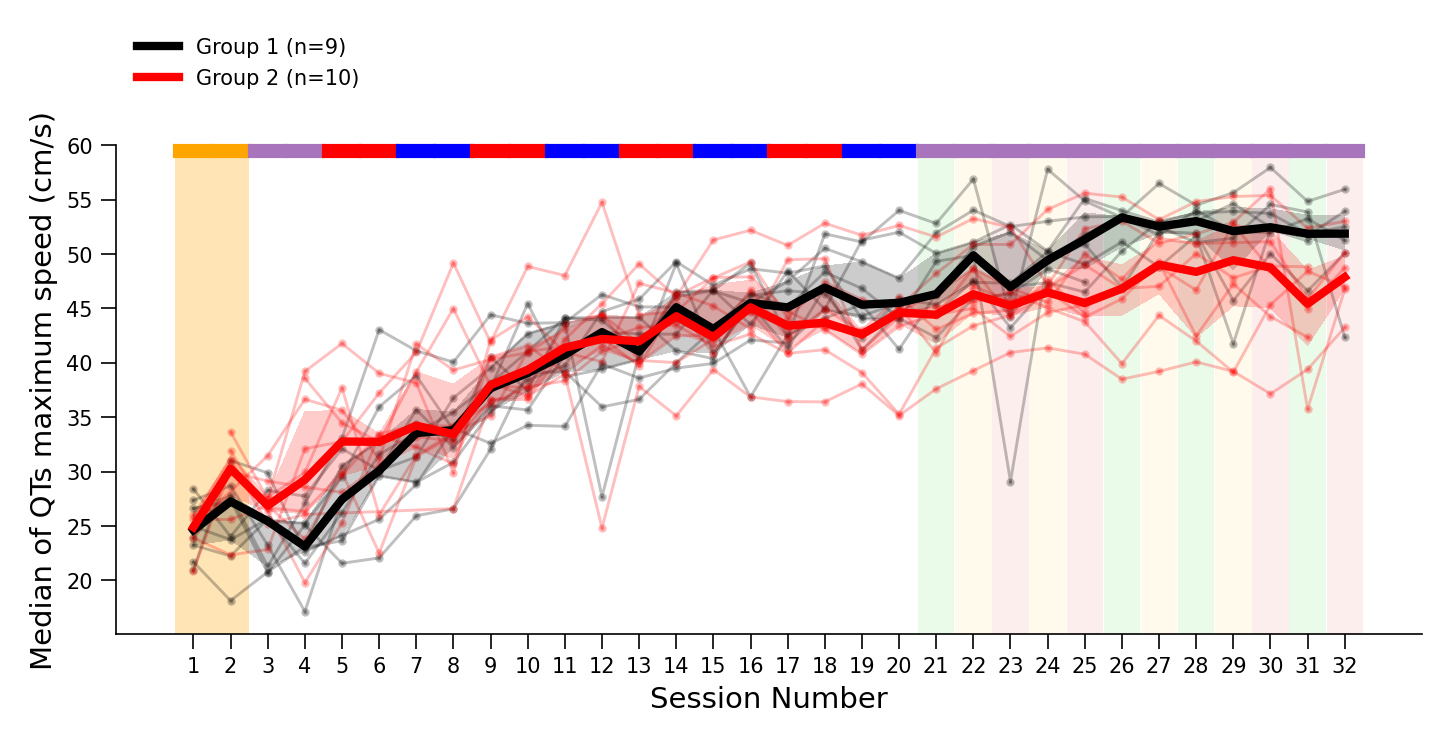

In [24]:
fig = plt.figure(figsize=(cm2inch(12), cm2inch(6)), dpi=300, facecolor='w')
ax = fig.add_subplot(111)

plot_learning_curves_two_groups(
    mouse_metric_persession=mouse_median_qt_maxspeed_persession,
    ax=ax,
    group1_mice=GROUP1_ANIMALS,
    group2_mice=GROUP2_ANIMALS,
    ylabel='Median of QTs maximum speed (cm/s)',
    legend_loc=(0.01, 1.1)
)


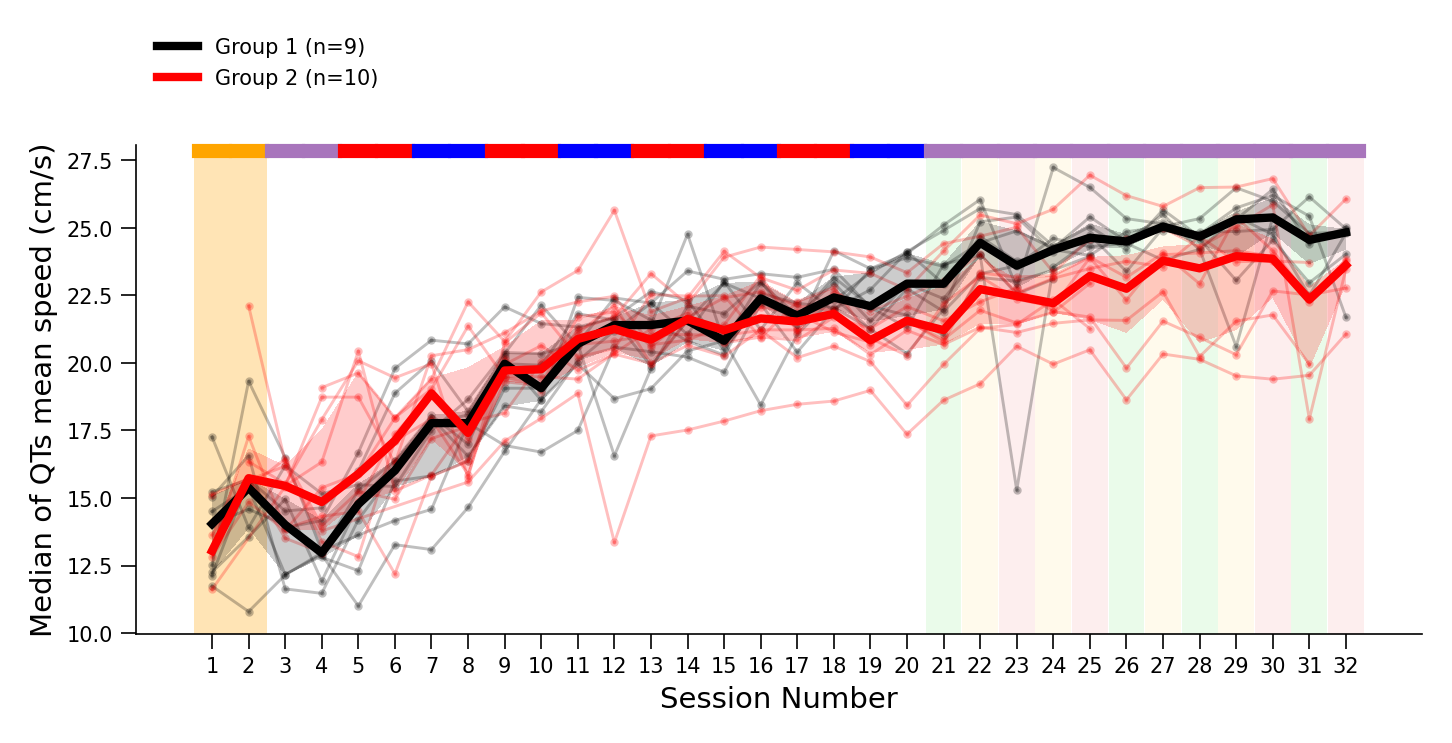

In [25]:
fig = plt.figure(figsize=(cm2inch(12), cm2inch(6)), dpi=300, facecolor='w')
ax = fig.add_subplot(111)

plot_learning_curves_two_groups(
    mouse_metric_persession=mouse_median_qt_meanspeed_persession,
    ax=ax,
    group1_mice=GROUP1_ANIMALS,
    group2_mice=GROUP2_ANIMALS,
    ylabel='Median of QTs mean speed (cm/s)',
    legend_loc=(0.01, 1.1)
)


/tmp/ipykernel_10505/3651628546.py:29: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


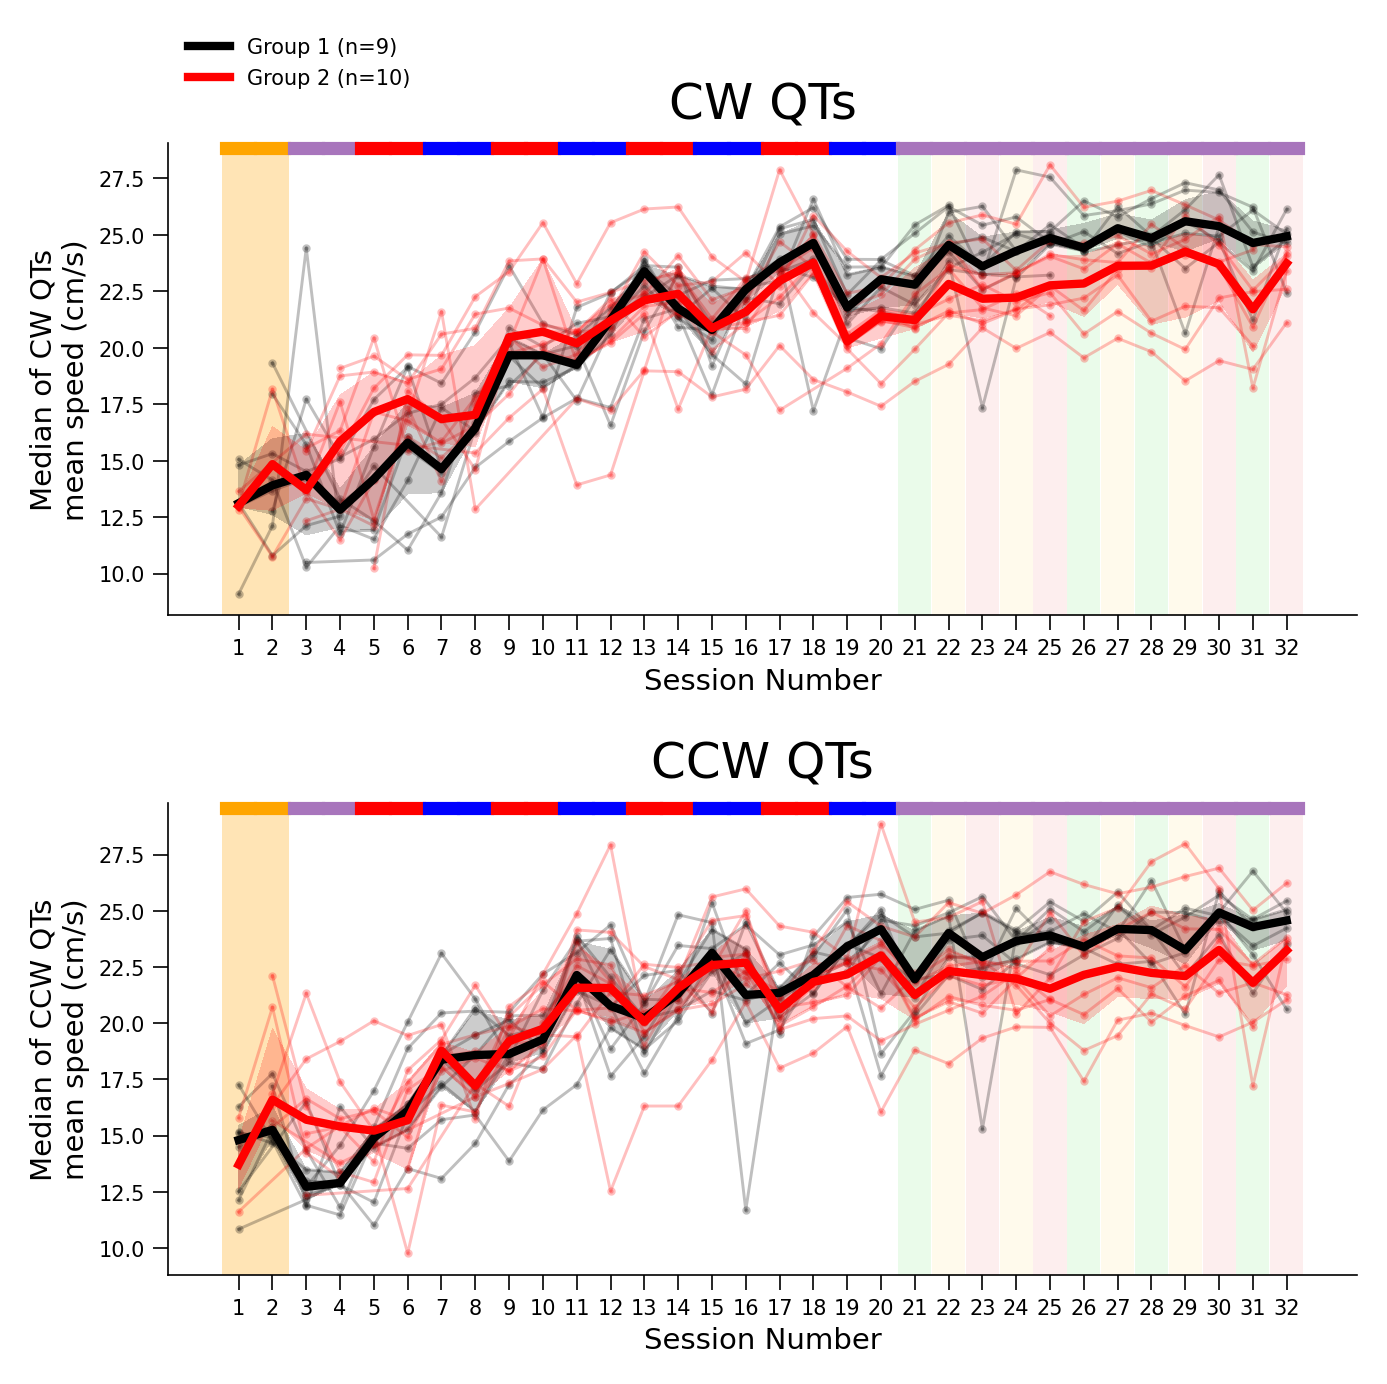

In [31]:
fig, axes = plt.subplots(2,1,figsize=(cm2inch(12), cm2inch(12)), dpi=300, facecolor='w')

# CW turns

plot_learning_curves_two_groups(
    mouse_metric_persession=mouse_median_cw_qt_meanspeed_persession,
    ax=axes[0],
    group1_mice=GROUP1_ANIMALS,
    group2_mice=GROUP2_ANIMALS,
    ylabel='Median of CW QTs\nmean speed (cm/s)',
    legend_loc=(0.01, 1.1)
)

axes[0].set_title("CW QTs")

# CCW turns

plot_learning_curves_two_groups(
    mouse_metric_persession=mouse_median_ccw_qt_meanspeed_persession,
    ax=axes[1],
    group1_mice=GROUP1_ANIMALS,
    group2_mice=GROUP2_ANIMALS,
    ylabel='Median of CCW QTs\nmean speed (cm/s)',
    show_legend=False
)

axes[1].set_title("CCW QTs")

plt.tight_layout()
plt.show()


/tmp/ipykernel_10505/1435284777.py:29: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


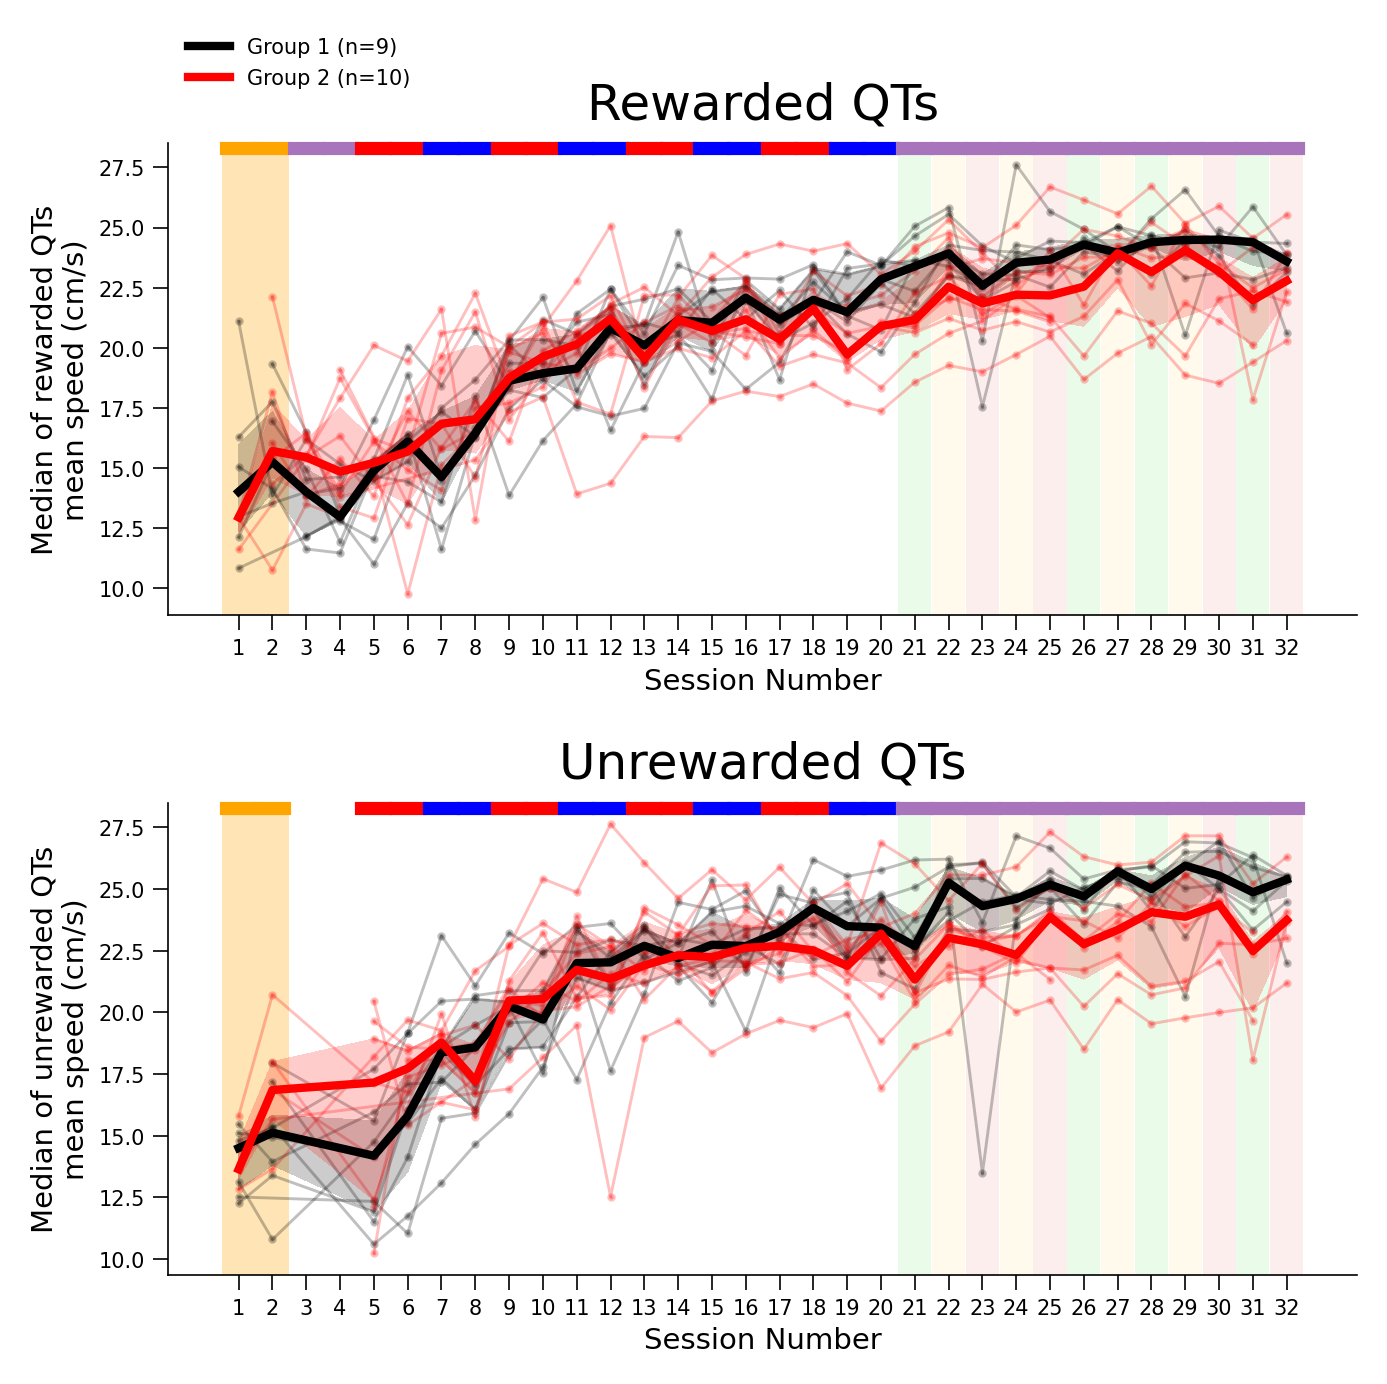

In [ ]:
fig, axes = plt.subplots(2,1,figsize=(cm2inch(12), cm2inch(12)), dpi=300, facecolor='w')

# CW turns

plot_learning_curves_two_groups(
    mouse_metric_persession=mouse_median_rewarded_qt_meanspeed_persession, # change "mean" to "max" to switch between the two metrics
    ax=axes[0],
    group1_mice=GROUP1_ANIMALS,
    group2_mice=GROUP2_ANIMALS,
    ylabel='Median of rewarded QTs\nmean speed (cm/s)',
    legend_loc=(0.01, 1.1)
)

axes[0].set_title("Rewarded QTs")

# CCW turns

plot_learning_curves_two_groups(
    mouse_metric_persession=mouse_median_unrewarded_qt_meanspeed_persession,
    ax=axes[1],
    group1_mice=GROUP1_ANIMALS,
    group2_mice=GROUP2_ANIMALS,
    ylabel='Median of unrewarded QTs\nmean speed (cm/s)',
    show_legend=False
)

axes[1].set_title("Unrewarded QTs")

plt.tight_layout()
plt.show()

### CW/CCW Ratio

Function(s)

In [69]:
def count_qts_by_direction(qts):
    """Count basic direction and reward statistics for a quarter-turn list.
    
    Parameters:
    qts : list. Quarter-turn epoch records.
    
    Returns:
    tuple[int, int, int]. total_qts is the total number of turns, cw_qts is the number with direction == "CW", and rewarded_qts is the number marked as rewarded."""

    total_qts = len(qts)
    cw_qts = sum(qt[3].get('direction') == 'CW' for qt in qts)
    rewarded_qts = sum(bool(qt[3].get('Rewarded', False)) for qt in qts)
    return total_qts, cw_qts, rewarded_qts


Data extraction

In [70]:
# Compute CW/CCW counts and a normalized direction-bias score for each session.

mouse_total_cw_persession = {mouse: [] for mouse in mice_to_analyse}
mouse_total_ccw_persession = {mouse: [] for mouse in mice_to_analyse}
mouse_ccw_vs_cw_norm_diff_persession = {mouse: [] for mouse in mice_to_analyse}

for mouse in mice_to_analyse:
    folder_path_mouse_to_process = os.path.join(path_to_data_folder, mouse)

    sessions_to_process = sorted([
        name for name in os.listdir(folder_path_mouse_to_process)
        if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
        and name.startswith('MOU')
    ])

    sessions_to_process = sessions_to_process[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    nb_sessions = len(sessions_to_process)
    print(f'Mouse {mouse}. There is/are {nb_sessions} sessions:')
    print(sessions_to_process, '\n')

    # First rewarded direction in the session series, used to align CW/CCW metrics.
    try:
        first_rewarded_direction = finding_mouse_rewarded_direction(
            folder_path_mouse_to_process,
            first_and_last_session_indexes[0]
        )
    except Exception:
        first_rewarded_direction = None

    for session_index, session_to_process in enumerate(sessions_to_process):
        session_number = session_index + 1
        absolute_session_index = first_and_last_session_indexes[0] + session_index

        try:
            rewarded_direction = finding_mouse_rewarded_direction(
                folder_path_mouse_to_process,
                absolute_session_index
            )
        except Exception:
            rewarded_direction = None

        output_pickle_filename = f"{session_to_process}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(
            folder_path_mouse_to_process,
            session_to_process,
            output_pickle_filename
        )

        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exist for session {session_to_process}, skipping .....')
            mouse_ccw_vs_cw_norm_diff_persession[mouse].append([session_number, np.nan])
            mouse_total_cw_persession[mouse].append([session_number, np.nan])
            mouse_total_ccw_persession[mouse].append([session_number, np.nan])
            continue

        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        # Filter quarter-turns before counting directions and rewarded turns.
        qts = filter_qts(session_data['all_epochs']['run_around_tower'])
        total_qts, cw_qts, rewarded_qts = count_qts_by_direction(qts)
        ccw_qts = total_qts - cw_qts

        if total_qts == 0:
            ccw_vs_cw_norm_diff = np.nan
        else:
            ccw_vs_cw_norm_diff = (ccw_qts - cw_qts) / total_qts

        if rewarded_direction == 'X':
            mouse_ccw_vs_cw_norm_diff_persession[mouse].append([session_number, ccw_vs_cw_norm_diff])
            mouse_total_cw_persession[mouse].append([session_number, cw_qts])
            mouse_total_ccw_persession[mouse].append([session_number, ccw_qts])

        elif first_rewarded_direction == 'CCW':
            # Match the previous notebook behavior by swapping CW and CCW when the first rewarded direction is CCW.
            mouse_ccw_vs_cw_norm_diff_persession[mouse].append([session_number, -ccw_vs_cw_norm_diff])
            mouse_total_cw_persession[mouse].append([session_number, ccw_qts])
            mouse_total_ccw_persession[mouse].append([session_number, cw_qts])

        else:
            mouse_ccw_vs_cw_norm_diff_persession[mouse].append([session_number, ccw_vs_cw_norm_diff])
            mouse_total_cw_persession[mouse].append([session_number, cw_qts])
            mouse_total_ccw_persession[mouse].append([session_number, ccw_qts])


Mouse MOUB6JRj749. There is/are 32 sessions:
['MOUB6JRj749_20260109-1312', 'MOUB6JRj749_20260109-1713', 'MOUB6JRj749_20260113-1138', 'MOUB6JRj749_20260113-1622', 'MOUB6JRj749_20260114-1127', 'MOUB6JRj749_20260114-1626', 'MOUB6JRj749_20260115-1118', 'MOUB6JRj749_20260115-1624', 'MOUB6JRj749_20260116-1130', 'MOUB6JRj749_20260116-1618', 'MOUB6JRj749_20260117-1119', 'MOUB6JRj749_20260117-1558', 'MOUB6JRj749_20260118-1121', 'MOUB6JRj749_20260118-1554', 'MOUB6JRj749_20260119-1101', 'MOUB6JRj749_20260119-1548', 'MOUB6JRj749_20260120-1118', 'MOUB6JRj749_20260120-1603', 'MOUB6JRj749_20260121-1047', 'MOUB6JRj749_20260121-1550', 'MOUB6JRj749_20260122-1102', 'MOUB6JRj749_20260122-1606', 'MOUB6JRj749_20260123-1127', 'MOUB6JRj749_20260123-1638', 'MOUB6JRj749_20260124-1122', 'MOUB6JRj749_20260124-1617', 'MOUB6JRj749_20260125-1056', 'MOUB6JRj749_20260125-1604', 'MOUB6JRj749_20260126-1045', 'MOUB6JRj749_20260126-1540', 'MOUB6JRj749_20260127-1107', 'MOUB6JRj749_20260127-1618'] 

Mouse MOUB6JRj750. There

Plot

/tmp/ipykernel_11158/4225921011.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


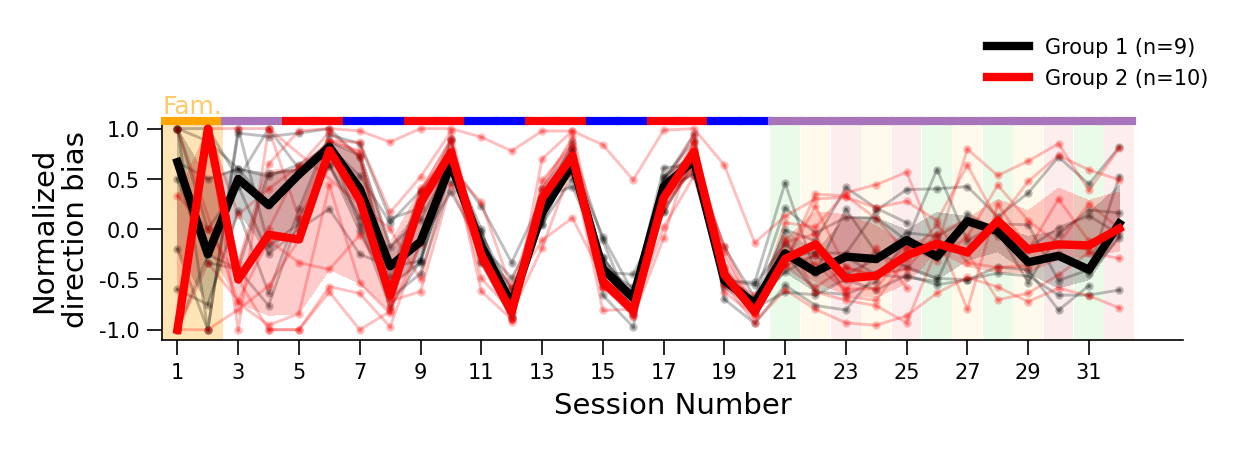

In [71]:
fig = plt.figure(figsize=(cm2inch(12), cm2inch(18)), dpi=300, constrained_layout=False, facecolor='w')
gs = fig.add_gridspec(5, 1, hspace=0.6)


ax = fig.add_subplot(gs[1, 0])

plot_learning_curves_two_groups(
    mouse_metric_persession=mouse_ccw_vs_cw_norm_diff_persession,
    ax=ax,
    group1_mice=GROUP1_ANIMALS,
    group2_mice=GROUP2_ANIMALS,
    group1_label='Group 1',
    group2_label='Group 2',
    group1_color='black',
    group2_color='red',
    ylabel='Normalized\ndirection bias',
    show_xlabel=True,
    tick_interval=2,
    index_offset=0,
    xlim=[0.5, None],
    show_fam=True,
    show_legend=True,
    legend_loc=(0.8, 1.1)
)

fig.tight_layout()
plt.subplots_adjust(left=0.18)
plt.show()


### Time to reach 80% of rewards
Function(s)

In [72]:
def accumulation_threshold(turns_time, threshold_fraction=0.8):
    """Return the event time at which a target fraction of events has accumulated.
    
    Parameters:
    turns_time : array-like. Event times, typically quarter-turn times within a session. NaN values are removed before computing the threshold.
    threshold_fraction : float, default=0.8. Fraction of events that must have occurred. For example, 0.8 returns the time of the 80th percentile event by count.
    
    Returns:
    float. Sorted event time at the requested accumulation threshold, or np.nan if no valid times are available."""

    turns_time = np.asarray(turns_time, dtype=float)
    turns_time = turns_time[~np.isnan(turns_time)]

    if len(turns_time) == 0:
        return np.nan

    turns_time = np.sort(turns_time)
    threshold_index = int(np.ceil(len(turns_time) * threshold_fraction)) - 1
    threshold_index = np.clip(threshold_index, 0, len(turns_time) - 1)

    return turns_time[threshold_index]

def qts_threshold_time(qts, direction=None, rewarded_only=False, threshold_fraction=0.8):
    """Compute an accumulation-threshold time after filtering quarter-turns.
    
    Parameters:
    qts : list. Quarter-turn epoch records.
    direction : str, iterable of str, or None, default=None. Direction filter.
    rewarded_only : bool, default=False. If True, keep only turns whose Rewarded metadata evaluates to True.
    threshold_fraction : float, default=0.8. Fraction passed to accumulation_threshold.
    
    Returns:
    float. Threshold accumulation time for the selected turns, or np.nan if no selected turn has a valid time."""

    if direction is None:
        allowed_directions = None
    elif isinstance(direction, (list, tuple, set)):
        allowed_directions = set(direction)
    else:
        allowed_directions = {direction}

    selected_times = []
    for qt in qts:
        qt_direction = qt[3].get('direction')
        qt_rewarded = bool(qt[3].get('Rewarded', False))

        if allowed_directions is not None and qt_direction not in allowed_directions:
            continue
        if rewarded_only and not qt_rewarded:
            continue

        selected_times.append(qt[4]['epoch_time'])

    return accumulation_threshold(selected_times, threshold_fraction=threshold_fraction)

def rewarded_turns_threshold_for_session(qts, rewarded_direction, threshold_fraction=0.8):

    """Compute the rewarded-turn accumulation threshold for the session reward rule.
    
    Parameters:
    qts : list. Quarter-turn epoch records for one session.
    rewarded_direction : {"CW", "CCW", "both"}. Reward rule for the session.
    threshold_fraction : float, default=0.8. Fraction of rewarded turns that must have accumulated.
    
    Returns:
    float.Time at which the requested fraction of rewarded turns has occurred, or np.nan."""

    if rewarded_direction == 'CW':
        return qts_threshold_time(
            qts,
            direction='CW',
            rewarded_only=True,
            threshold_fraction=threshold_fraction
        )

    elif rewarded_direction == 'CCW':
        return qts_threshold_time(
            qts,
            direction='CCW',
            rewarded_only=True,
            threshold_fraction=threshold_fraction
        )

    elif rewarded_direction == 'both':
        return qts_threshold_time(
            qts,
            direction=['CW', 'CCW'],
            rewarded_only=True,
            threshold_fraction=threshold_fraction
        )

    else:
        return np.nan


Data extraction

In [73]:
# Compute the time needed to reach the selected fraction of rewarded turns in each session.

mouse_rewardedturns_threshold_persession = {mouse: [] for mouse in mice_to_analyse}

for mouse in mice_to_analyse:
    folder_path_mouse_to_process = os.path.join(path_to_data_folder, mouse)

    sessions_to_process = sorted([
        name for name in os.listdir(folder_path_mouse_to_process)
        if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
        and name.startswith('MOU')
    ])

    sessions_to_process = sessions_to_process[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    nb_sessions = len(sessions_to_process)
    print(f'Mouse {mouse}. There is/are {nb_sessions} sessions:')
    print(sessions_to_process, '\n')

    for session_index, session_to_process in enumerate(sessions_to_process):
        session_number = session_index + 1
        absolute_session_index = first_and_last_session_indexes[0] + session_index

        try:
            rewarded_direction = finding_mouse_rewarded_direction(
                folder_path_mouse_to_process,
                absolute_session_index
            )
        except Exception:
            rewarded_direction = None

        output_pickle_filename = f"{session_to_process}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(
            folder_path_mouse_to_process,
            session_to_process,
            output_pickle_filename
        )

        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exist for session {session_to_process}, skipping .....')
            mouse_rewardedturns_threshold_persession[mouse].append([session_number, np.nan])
            continue

        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        # Filter quarter-turns before counting directions and rewarded turns.
        qts = filter_qts(session_data['all_epochs']['run_around_tower'])
        total_qts, cw_qts, rewarded_qts = count_qts_by_direction(qts)

        rewarded_turns_threshold_time = rewarded_turns_threshold_for_session(qts,rewarded_direction,threshold_fraction=0.8)

        mouse_rewardedturns_threshold_persession[mouse].append([session_number, rewarded_turns_threshold_time])


Mouse MOUB6JRj749. There is/are 32 sessions:
['MOUB6JRj749_20260109-1312', 'MOUB6JRj749_20260109-1713', 'MOUB6JRj749_20260113-1138', 'MOUB6JRj749_20260113-1622', 'MOUB6JRj749_20260114-1127', 'MOUB6JRj749_20260114-1626', 'MOUB6JRj749_20260115-1118', 'MOUB6JRj749_20260115-1624', 'MOUB6JRj749_20260116-1130', 'MOUB6JRj749_20260116-1618', 'MOUB6JRj749_20260117-1119', 'MOUB6JRj749_20260117-1558', 'MOUB6JRj749_20260118-1121', 'MOUB6JRj749_20260118-1554', 'MOUB6JRj749_20260119-1101', 'MOUB6JRj749_20260119-1548', 'MOUB6JRj749_20260120-1118', 'MOUB6JRj749_20260120-1603', 'MOUB6JRj749_20260121-1047', 'MOUB6JRj749_20260121-1550', 'MOUB6JRj749_20260122-1102', 'MOUB6JRj749_20260122-1606', 'MOUB6JRj749_20260123-1127', 'MOUB6JRj749_20260123-1638', 'MOUB6JRj749_20260124-1122', 'MOUB6JRj749_20260124-1617', 'MOUB6JRj749_20260125-1056', 'MOUB6JRj749_20260125-1604', 'MOUB6JRj749_20260126-1045', 'MOUB6JRj749_20260126-1540', 'MOUB6JRj749_20260127-1107', 'MOUB6JRj749_20260127-1618'] 

Mouse MOUB6JRj750. There

Plot

/tmp/ipykernel_11158/753658870.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


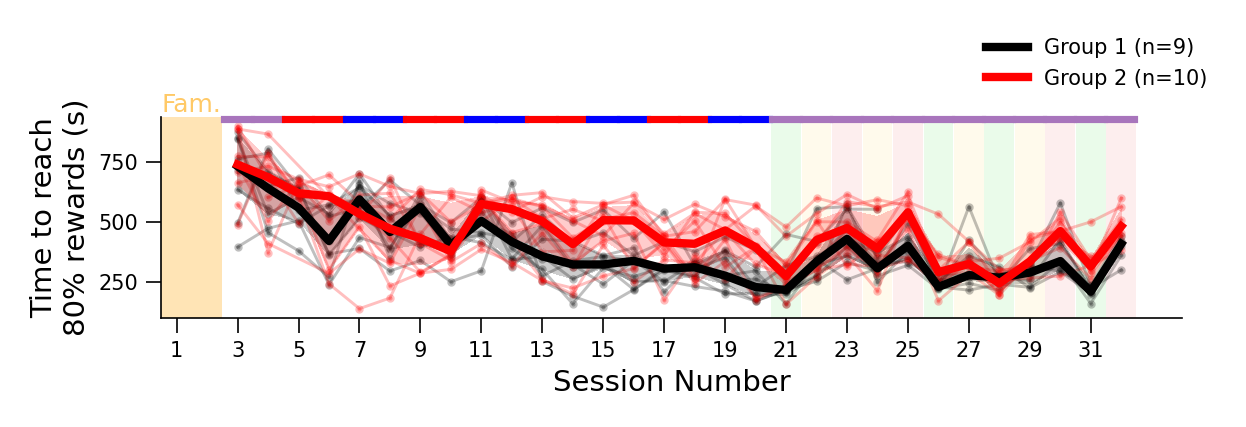

In [74]:
fig = plt.figure(figsize=(cm2inch(12), cm2inch(15)), dpi=300, constrained_layout=False, facecolor='w')
gs = fig.add_gridspec(5, 1, hspace=0.45)

row1 = gs[4].subgridspec(1, 1)
ax_1 = plt.subplot(row1[0, 0])

plot_learning_curves_two_groups(
    mouse_metric_persession=mouse_rewardedturns_threshold_persession,
    ax=ax_1,
    group1_mice=GROUP1_ANIMALS,
    group2_mice=GROUP2_ANIMALS,
    group1_label='Group 1',
    group2_label='Group 2',
    group1_color='black',
    group2_color='red',
    ylabel='Time to reach\n80% rewards (s)',
    show_xlabel=True,
    tick_interval=2,
    index_offset=0,
    xlim=[0.5, None],
    show_fam=True,
    legend_loc=(0.8, 1.1)
)

fig.tight_layout()
plt.subplots_adjust(left=0.18)
plt.show()


### Number of rewarded/unrewarded turns

Data extraction

In [75]:
# Compute total rewarded and unrewarded turns for each mouse and session.

mouse_rewarded_turns_persession = {mouse: [] for mouse in mice_to_analyse}
mouse_unrewarded_turns_persession = {mouse: [] for mouse in mice_to_analyse}

for mouse in mice_to_analyse:

    folder_path_mouse_to_process = os.path.join(path_to_data_folder, mouse)

    sessions_to_process = sorted([
        name for name in os.listdir(folder_path_mouse_to_process)
        if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
        and name.startswith('MOU')
    ])

    sessions_to_process = sessions_to_process[
        first_and_last_session_indexes[0]:
        first_and_last_session_indexes[1]
    ]

    print(f'Mouse {mouse}. There is/are {len(sessions_to_process)} sessions:')
    print(sessions_to_process, '\n')

    for session_index, session_to_process in enumerate(sessions_to_process):

        session_number = session_index + 1

        output_pickle_filename = (
            f"{session_to_process}_basic_processing_output.pickle"
        )

        output_pickle_filepath = os.path.join(
            folder_path_mouse_to_process,
            session_to_process,
            output_pickle_filename
        )

        if not os.path.exists(output_pickle_filepath):

            mouse_rewarded_turns_persession[mouse].append(
                [session_number, np.nan]
            )

            mouse_unrewarded_turns_persession[mouse].append(
                [session_number, np.nan]
            )

            continue

        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        # Filter quarter-turns
        qts = filter_qts(session_data['all_epochs']['run_around_tower'])

        # Count turns
        total_qts, cw_qts, rewarded_qts = count_qts_by_direction(qts)

        unrewarded_qts = total_qts - rewarded_qts

        mouse_rewarded_turns_persession[mouse].append(
            [session_number, rewarded_qts]
        )

        mouse_unrewarded_turns_persession[mouse].append(
            [session_number, unrewarded_qts]
        )

Mouse MOUB6JRj749. There is/are 32 sessions:
['MOUB6JRj749_20260109-1312', 'MOUB6JRj749_20260109-1713', 'MOUB6JRj749_20260113-1138', 'MOUB6JRj749_20260113-1622', 'MOUB6JRj749_20260114-1127', 'MOUB6JRj749_20260114-1626', 'MOUB6JRj749_20260115-1118', 'MOUB6JRj749_20260115-1624', 'MOUB6JRj749_20260116-1130', 'MOUB6JRj749_20260116-1618', 'MOUB6JRj749_20260117-1119', 'MOUB6JRj749_20260117-1558', 'MOUB6JRj749_20260118-1121', 'MOUB6JRj749_20260118-1554', 'MOUB6JRj749_20260119-1101', 'MOUB6JRj749_20260119-1548', 'MOUB6JRj749_20260120-1118', 'MOUB6JRj749_20260120-1603', 'MOUB6JRj749_20260121-1047', 'MOUB6JRj749_20260121-1550', 'MOUB6JRj749_20260122-1102', 'MOUB6JRj749_20260122-1606', 'MOUB6JRj749_20260123-1127', 'MOUB6JRj749_20260123-1638', 'MOUB6JRj749_20260124-1122', 'MOUB6JRj749_20260124-1617', 'MOUB6JRj749_20260125-1056', 'MOUB6JRj749_20260125-1604', 'MOUB6JRj749_20260126-1045', 'MOUB6JRj749_20260126-1540', 'MOUB6JRj749_20260127-1107', 'MOUB6JRj749_20260127-1618'] 

Mouse MOUB6JRj750. There

Plots

/tmp/ipykernel_11158/3073802089.py:29: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


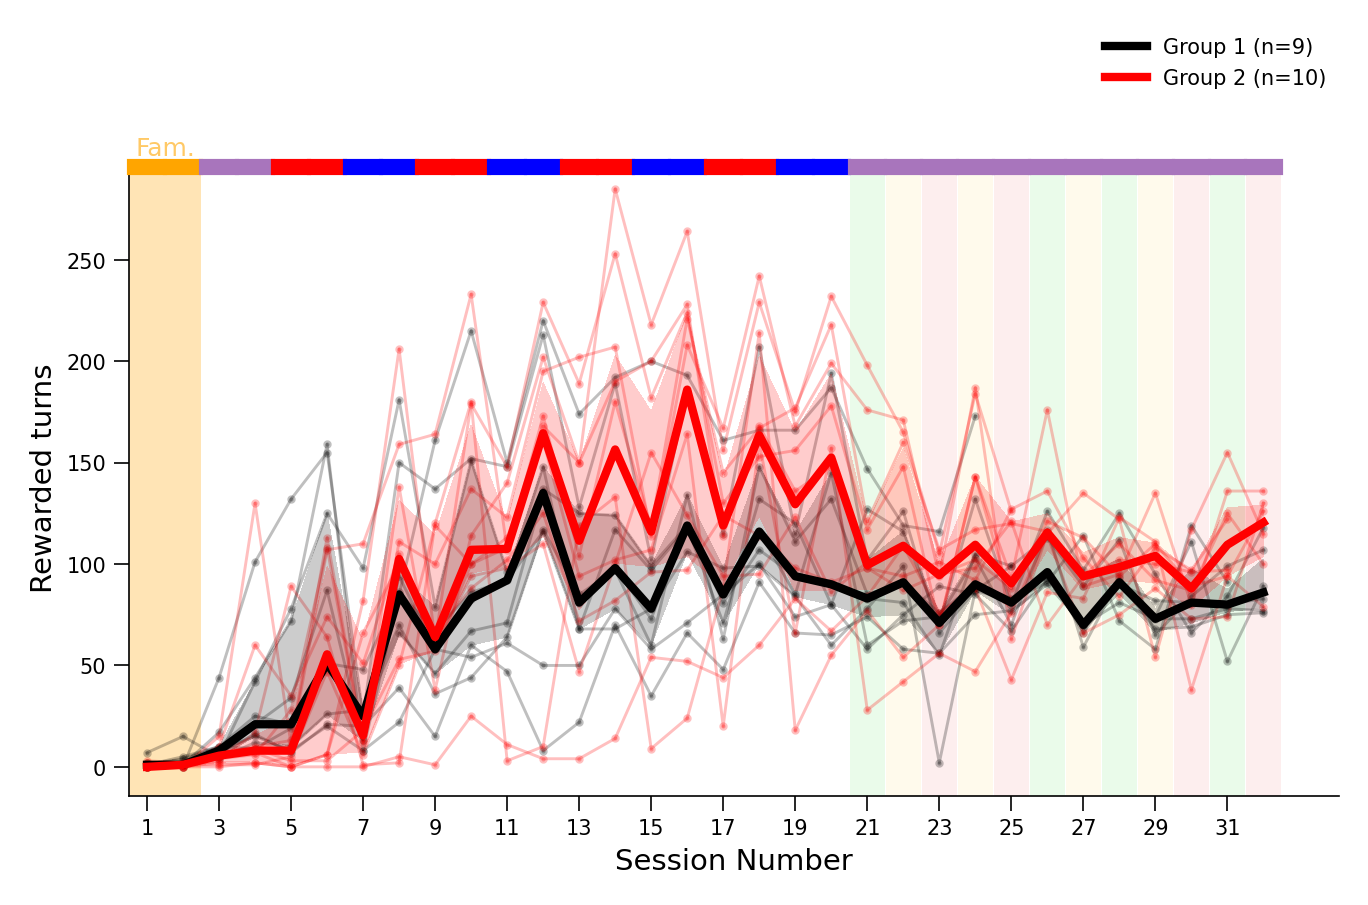

In [76]:
# Rewarded turns

fig = plt.figure(
    figsize=(cm2inch(12), cm2inch(8)),
    dpi=300,
    facecolor='w'
)

ax = fig.add_subplot(111)

plot_learning_curves_two_groups(
    mouse_metric_persession=mouse_rewarded_turns_persession,
    ax=ax,
    group1_mice=GROUP1_ANIMALS,
    group2_mice=GROUP2_ANIMALS,
    group1_label='Group 1',
    group2_label='Group 2',
    group1_color='black',
    group2_color='red',
    ylabel='Rewarded turns',
    show_xlabel=True,
    tick_interval=2,
    index_offset=0,
    xlim=[0.5, None],
    show_fam=True,
    legend_loc=(0.8, 1.1)
)

fig.tight_layout()
plt.show()


/tmp/ipykernel_11158/2072101608.py:29: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


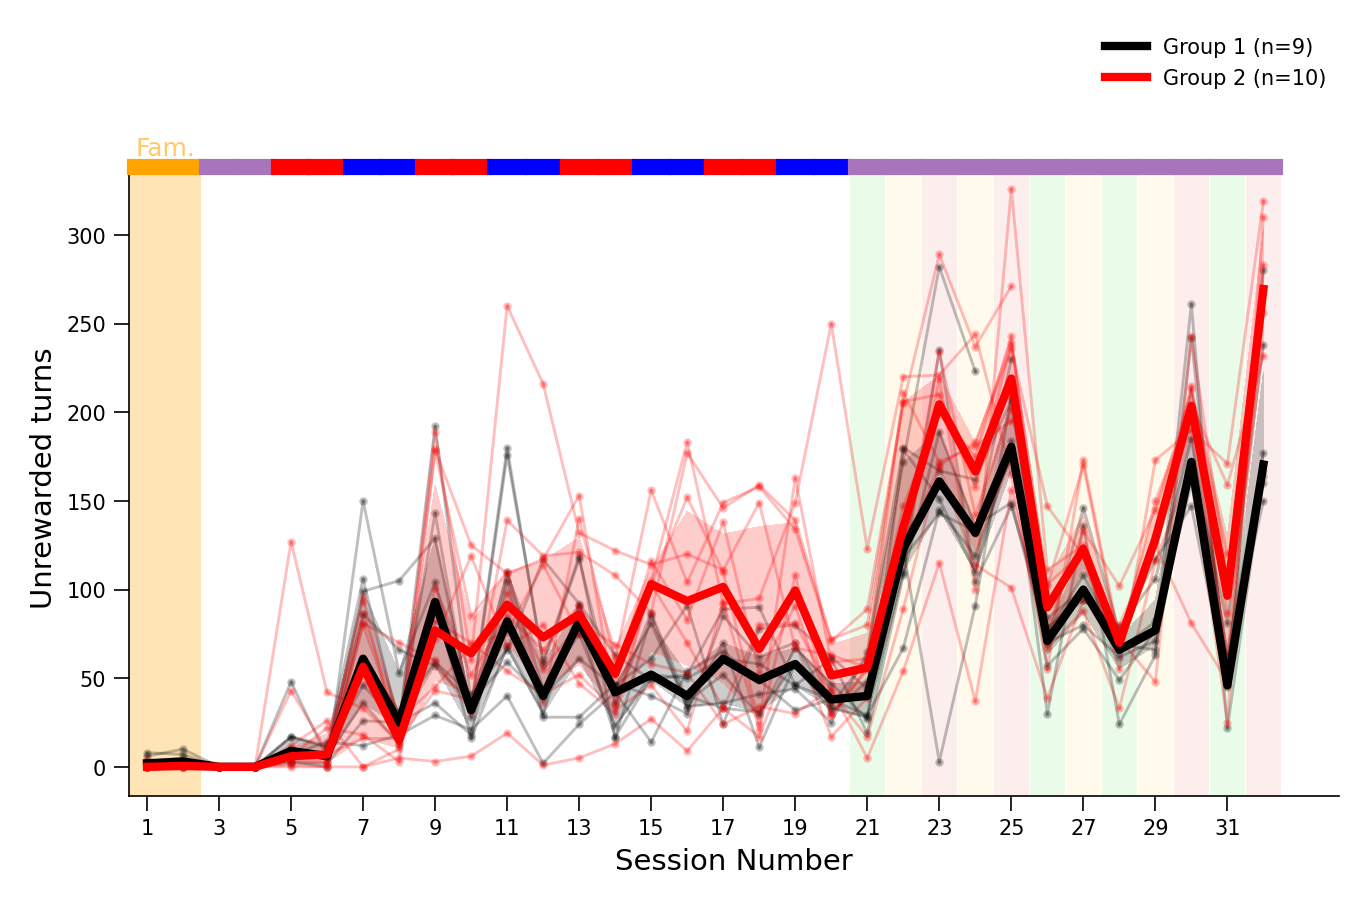

In [77]:
# Unrewarded turns

fig = plt.figure(
    figsize=(cm2inch(12), cm2inch(8)),
    dpi=300,
    facecolor='w'
)

ax = fig.add_subplot(111)

plot_learning_curves_two_groups(
    mouse_metric_persession=mouse_unrewarded_turns_persession,
    ax=ax,
    group1_mice=GROUP1_ANIMALS,
    group2_mice=GROUP2_ANIMALS,
    group1_label='Group 1',
    group2_label='Group 2',
    group1_color='black',
    group2_color='red',
    ylabel='Unrewarded turns',
    show_xlabel=True,
    tick_interval=2,
    index_offset=0,
    xlim=[0.5, None],
    show_fam=True,
    legend_loc=(0.8, 1.1)
)

fig.tight_layout()
plt.show()


### Number of CW/CCW turns

Data extraction

In [79]:
mouse_cw_turns_persession = {mouse: [] for mouse in mice_to_analyse}
mouse_ccw_turns_persession = {mouse: [] for mouse in mice_to_analyse}

for mouse in mice_to_analyse:

    folder_path_mouse_to_process = os.path.join(path_to_data_folder, mouse)

    sessions_to_process = sorted([
        name for name in os.listdir(folder_path_mouse_to_process)
        if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
        and name.startswith('MOU')
    ])

    sessions_to_process = sessions_to_process[
        first_and_last_session_indexes[0]:
        first_and_last_session_indexes[1]
    ]

    for session_index, session_to_process in enumerate(sessions_to_process):

        session_number = session_index + 1

        output_pickle_filename = f"{session_to_process}_basic_processing_output.pickle"

        output_pickle_filepath = os.path.join(
            folder_path_mouse_to_process,
            session_to_process,
            output_pickle_filename
        )

        if not os.path.exists(output_pickle_filepath):
            mouse_cw_turns_persession[mouse].append([session_number, np.nan])
            mouse_ccw_turns_persession[mouse].append([session_number, np.nan])
            continue

        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        qts = filter_qts(session_data['all_epochs']['run_around_tower'])

        total_qts, cw_qts, rewarded_qts = count_qts_by_direction(qts)

        ccw_qts = total_qts - cw_qts

        mouse_cw_turns_persession[mouse].append([session_number, cw_qts])
        mouse_ccw_turns_persession[mouse].append([session_number, ccw_qts])

Plots

/tmp/ipykernel_11158/490943593.py:25: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


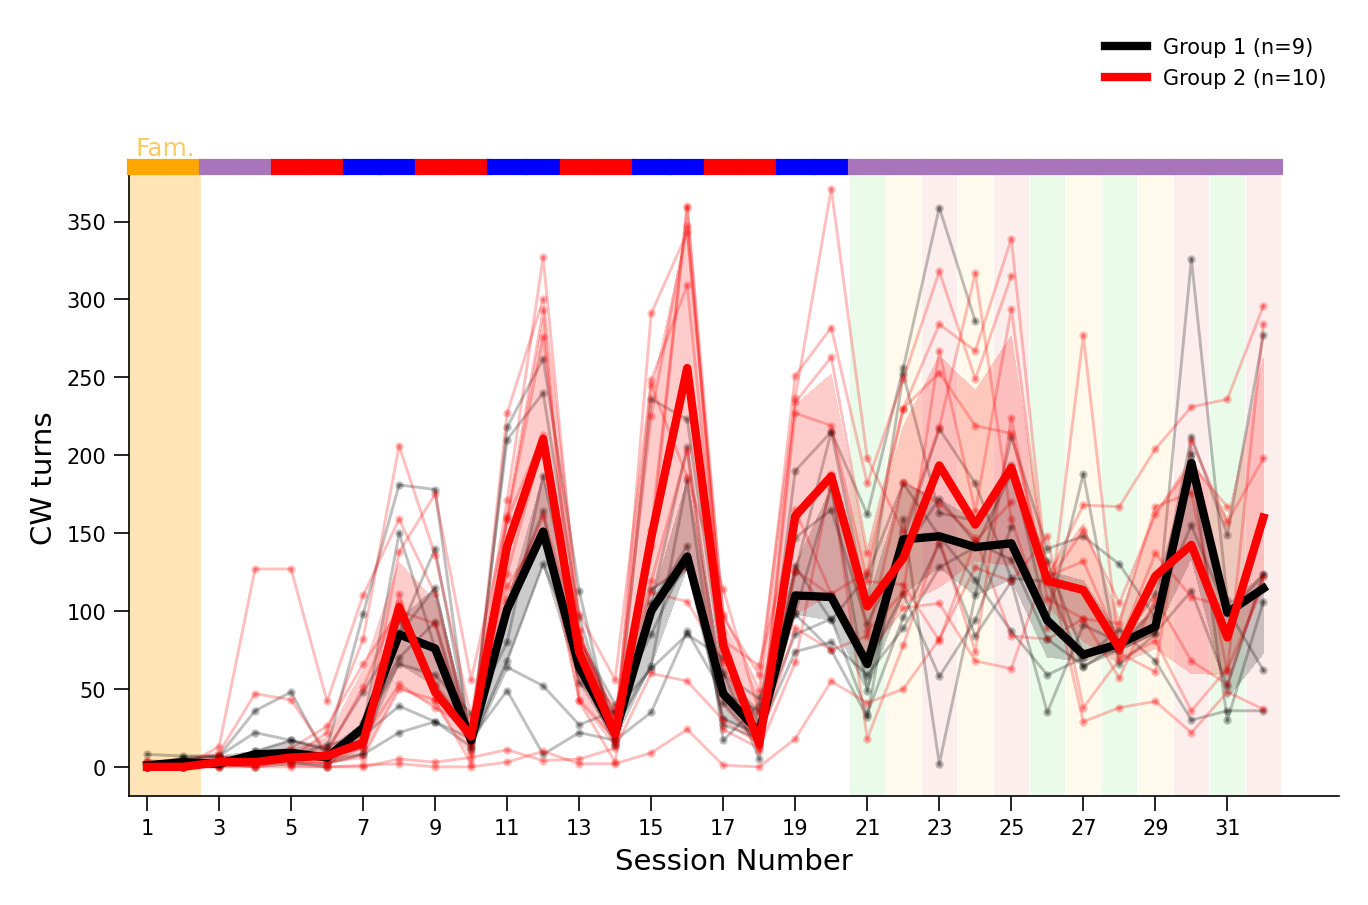

In [80]:
# CW turns 

fig = plt.figure(figsize=(cm2inch(12), cm2inch(8)), dpi=300, facecolor='w')
ax = fig.add_subplot(111)

plot_learning_curves_two_groups(
    mouse_metric_persession=mouse_cw_turns_persession,
    ax=ax,
    group1_mice=GROUP1_ANIMALS,
    group2_mice=GROUP2_ANIMALS,
    group1_label='Group 1',
    group2_label='Group 2',
    group1_color='black',
    group2_color='red',
    ylabel='CW turns',
    show_xlabel=True,
    tick_interval=2,
    index_offset=0,
    xlim=[0.5, None],
    show_fam=True,
    legend_loc=(0.8, 1.1),
    show_individual_mice=True
)

fig.tight_layout()
plt.show()


/tmp/ipykernel_11158/3637566978.py:25: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


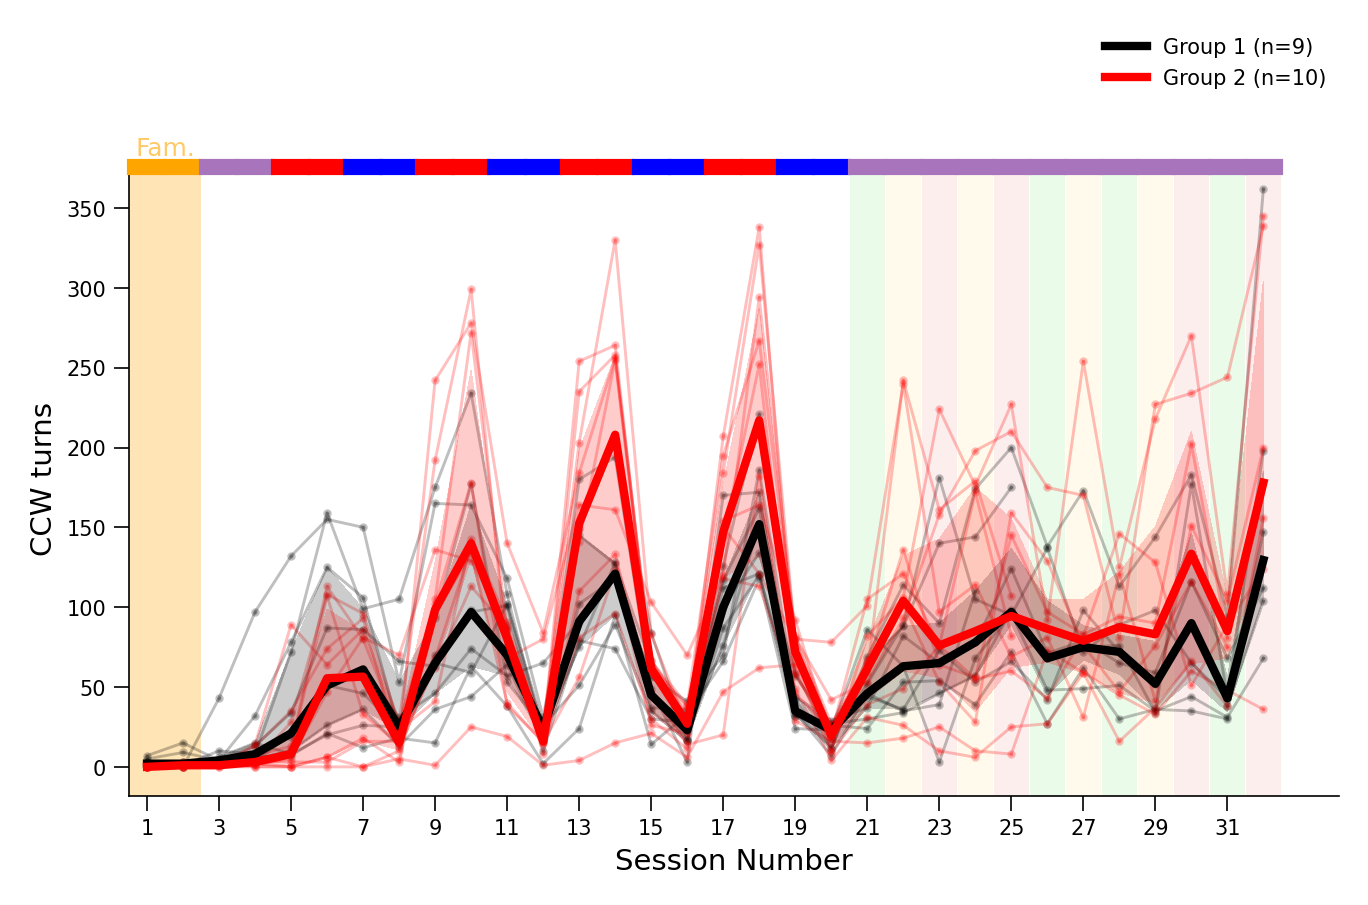

In [81]:
# CCW turns

fig = plt.figure(figsize=(cm2inch(12), cm2inch(8)), dpi=300, facecolor='w')
ax = fig.add_subplot(111)

plot_learning_curves_two_groups(
    mouse_metric_persession=mouse_ccw_turns_persession,
    ax=ax,
    group1_mice=GROUP1_ANIMALS,
    group2_mice=GROUP2_ANIMALS,
    group1_label='Group 1',
    group2_label='Group 2',
    group1_color='black',
    group2_color='red',
    ylabel='CCW turns',
    show_xlabel=True,
    tick_interval=2,
    index_offset=0,
    xlim=[0.5, None],
    show_fam=True,
    legend_loc=(0.8, 1.1),
    show_individual_mice=True
)

fig.tight_layout()
plt.show()
